# 08 — Restart-safe MD simulations of sequence-threaded PD-L1 mini-binder complexes

This notebook runs short comparative MD simulations on **sequence-threaded binder–PD-L1 complex PDBs**.

The MD input is constructed from:

```text
RFdiffusion complex backbone/pose + ProteinMPNN binder sequence → sequence-threaded complex → PDBFixer sidechain/H addition → solvation → MD
```

This avoids the earlier failure mode where MD accidentally used `rfdiffusion_outputs/*.pdb` directly, leaving the binder as poly-G. It also avoids treating `esmfold_predictions/*.pdb` as complexes when they are binder-only predictions.

The notebook is written to be **restart-safe** for Colab: completed stages are detected from Drive outputs and skipped unless force flags are enabled.


## Cell 0 — Install dependencies and check GPU

Run once per Colab session. Use **Runtime → Change runtime type → T4 GPU**.


In [ ]:
import sys, os, subprocess, textwrap

print("Python:", sys.version)
print("\n--- nvidia-smi ---")
try:
    subprocess.run(["nvidia-smi"], check=False)
except Exception as e:
    print("nvidia-smi failed:", e)

# OpenMM in this Colab image may expose OpenCL but not CUDA. OpenCL works on the T4.
# We install standard OpenMM plus tools; if CUDA is available later, the notebook can use it.
!pip install -q --upgrade openmm pdbfixer mdtraj matplotlib numpy pandas biopython

import openmm
from openmm import Platform
import mdtraj as md

print("\nOpenMM version:", openmm.version.version)
print("Available OpenMM platforms:")
for i in range(Platform.getNumPlatforms()):
    print(" ", i, Platform.getPlatform(i).getName())

print("MDTraj version:", md.__version__)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

--- nvidia-smi ---
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 665.9/665.9 kB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 126.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 122.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency con

## Cell 1 — Mount Drive, config, imports, and global settings

Change `PROJECT_DIR` if your project path differs.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from collections import Counter, defaultdict
import json
import pickle
import shutil
import time as _time
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openmm
from openmm import LangevinMiddleIntegrator, MonteCarloBarostat, CustomExternalForce, Platform, unit
from openmm.app import (
    PDBFile, Modeller, ForceField, Simulation, StateDataReporter,
    DCDReporter, CheckpointReporter, PME, HBonds
)
from pdbfixer import PDBFixer
import mdtraj as md

# -----------------------------
# Project paths
# -----------------------------
PROJECT_DIR = Path("/content/drive/Othercomputers/My Mac/pdl1-mini-binder-design")
DATA_DIR = PROJECT_DIR / "data"
RESULTS_DIR = DATA_DIR / "results"
STRUCTURES_DIR = DATA_DIR / "structures"
STUDY_DIR = RESULTS_DIR / "param_sensitivity"
PARAM_SENSITIVITY_DIR = STUDY_DIR
ESMFOLD_SUBDIR = "esmfold_predictions"
RFDIFFUSION_SUBDIR = "rfdiffusion_outputs"
THREADED_SUBDIR = "sequence_threaded_complexes"

# Ranked candidates CSV: support both locations used by earlier notebooks.
RANKED_CSV_CANDIDATES = [
    STUDY_DIR / "ranked_candidates_all_conditions.csv",
    RESULTS_DIR / "ranked_candidates_all_conditions.csv",
]
RANKED_CSV = next((p for p in RANKED_CSV_CANDIDATES if p.exists()), RANKED_CSV_CANDIDATES[0])

# Backward-compatible aliases used by later cells / pasted patches.
RANKED_CANDIDATES_CSV = RANKED_CSV

# Use a fresh output folder so sequence-threaded MD outputs do not mix with earlier accidental poly-G/RFdiffusion runs.
MD_OUTPUT_DIR = RESULTS_DIR / "md_simulations_threaded_complexes"
MD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Temporary local workdir. Can disappear on disconnect; Drive outputs are durable.
WORK_DIR = Path("/content/md_work_threaded_complexes")
WORK_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = MD_OUTPUT_DIR / "md_manifest.csv"
SUMMARY_PATH = MD_OUTPUT_DIR / "md_simulation_summary.csv"
METADATA_PATH = MD_OUTPUT_DIR / "md_metadata.json"

# Backward-compatible aliases used by later cells / pasted patches.
MD_MANIFEST_PATH = MANIFEST_PATH

# -----------------------------
# Runtime behavior
# -----------------------------
PLATFORM_NAME = "OpenCL"    # In this Colab session OpenCL is available on T4; CUDA may not be registered.
FORCE_REPREPARE = False
FORCE_MINIMIZE = False
FORCE_EQUILIBRATE = False
FORCE_PRODUCTION = False
FORCE_ANALYSIS = True       # analysis is cheap; okay to overwrite plots/metrics
FORCE_THREAD_COMPLEXES = False

# For explicitly simulating RFdiffusion poly-G negative controls, set True for those cases only.
ALLOW_POLY_G_INPUTS = False

# -----------------------------
# MD protocol
# -----------------------------
SOLVENT_PADDING_NM = 1.0
IONIC_STRENGTH_M = 0.15
TEMPERATURE_K = 300
PRESSURE_BAR = 1.0
PH = 7.0

NVT_STEPS = 50_000          # 100 ps at 2 fs
NPT_STEPS = 100_000         # 200 ps at 2 fs
NVT_DT_PS = 0.002
NPT_DT_PS = 0.002

PRODUCTION_NS = 1         # Start with 0.1 ns smoke test; then 1; then 10.
PRODUCTION_DT_PS = 0.001    # Conservative 1 fs. Move to 2 fs only after stable runs.
REPORT_PS = 10
CHECKPOINT_PS = 100
WARMUP_PS = 10

# Candidate selection
MAX_CANDIDATES = 3
HOTSPOT_PRIORITY = ["clusterA", "distributed", "clusterB"]

print("PROJECT_DIR:", PROJECT_DIR, PROJECT_DIR.exists())
print("RANKED_CSV:", RANKED_CSV, RANKED_CSV.exists())
print("MD_OUTPUT_DIR:", MD_OUTPUT_DIR)
print("WORK_DIR:", WORK_DIR)
print("RFdiffusion pose source layout:", PARAM_SENSITIVITY_DIR / "{condition_id}" / RFDIFFUSION_SUBDIR / "{backbone}.pdb")
print("ESMFold binder validation layout:", PARAM_SENSITIVITY_DIR / "{condition_id}" / ESMFOLD_SUBDIR / "{seq_id}.pdb")
print("Threaded complex output layout:", PARAM_SENSITIVITY_DIR / "{condition_id}" / THREADED_SUBDIR / "{seq_id}_threaded_complex.pdb")
print("MANIFEST_PATH:", MANIFEST_PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design True
RANKED_CSV: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/ranked_candidates_all_conditions.csv True
MD_OUTPUT_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes
WORK_DIR: /content/md_work_threaded_complexes
RFdiffusion pose source layout: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/{condition_id}/rfdiffusion_outputs/{backbone}.pdb
ESMFold binder validation layout: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/{condition_id}/esmfold_predictions/{seq_id}.pdb
Threaded complex output layout: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/{cond

## Cell 2 — Utility functions: platforms, manifests, PDB sequence validation

This is the backbone of the restart-safe behavior.


In [ ]:
# ============================================================
# Cell 2 — Utility functions: platforms, manifests, PDB sequence validation
# ============================================================

from pathlib import Path
from collections import Counter, defaultdict
import shutil
import json
import numpy as np
import pandas as pd

THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "SEC": "U", "PYL": "O",
}

ONE_TO_THREE = {v: k for k, v in THREE_TO_ONE.items() if len(v) == 1}
BACKBONE_ATOMS = {"N", "CA", "C", "O", "OXT"}


# ------------------------------------------------------------
# Restart-safe config aliases
# ------------------------------------------------------------
# Earlier notebook versions used both naming conventions:
#   RANKED_CSV / MANIFEST_PATH
#   RANKED_CANDIDATES_CSV / MD_MANIFEST_PATH
# This block makes both valid.

if "PROJECT_DIR" not in globals():
    PROJECT_DIR = Path("/content/drive/Othercomputers/My Mac/pdl1-mini-binder-design")

if "RESULTS_DIR" not in globals():
    RESULTS_DIR = PROJECT_DIR / "data" / "results"

if "PARAM_SENSITIVITY_DIR" not in globals():
    PARAM_SENSITIVITY_DIR = RESULTS_DIR / "param_sensitivity"

if "MD_OUTPUT_DIR" not in globals():
    MD_OUTPUT_DIR = RESULTS_DIR / "md_simulations_threaded_complexes"

if "WORK_DIR" not in globals():
    WORK_DIR = Path("/content/md_work_threaded_complexes")

# Resolve ranked candidates CSV robustly.
if "RANKED_CSV" not in globals():
    candidate_ranked_paths = [
        PARAM_SENSITIVITY_DIR / "ranked_candidates_all_conditions.csv",
        RESULTS_DIR / "ranked_candidates_all_conditions.csv",
    ]

    existing_ranked_paths = [p for p in candidate_ranked_paths if p.exists()]

    if len(existing_ranked_paths) == 0:
        # Define default anyway so downstream error messages are informative.
        RANKED_CSV = candidate_ranked_paths[0]
    else:
        RANKED_CSV = existing_ranked_paths[0]

if "RANKED_CANDIDATES_CSV" not in globals():
    RANKED_CANDIDATES_CSV = RANKED_CSV

if "MANIFEST_PATH" not in globals():
    MANIFEST_PATH = MD_OUTPUT_DIR / "md_manifest.csv"

if "MD_MANIFEST_PATH" not in globals():
    MD_MANIFEST_PATH = MANIFEST_PATH

if "PRODUCTION_NS" not in globals():
    PRODUCTION_NS = 0.1

if "PLATFORM_NAME" not in globals():
    PLATFORM_NAME = "OpenCL"

if "FORCE_THREAD_COMPLEXES" not in globals():
    FORCE_THREAD_COMPLEXES = False

if "FORCE_REPREPARE" not in globals():
    FORCE_REPREPARE = False

if "FORCE_MINIMIZE" not in globals():
    FORCE_MINIMIZE = False

if "FORCE_EQUILIBRATE" not in globals():
    FORCE_EQUILIBRATE = False

if "FORCE_PRODUCTION" not in globals():
    FORCE_PRODUCTION = False

if "FORCE_ANALYSIS" not in globals():
    FORCE_ANALYSIS = False

MD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Platform helpers
# ------------------------------------------------------------

def get_platform_properties(platform_name=PLATFORM_NAME):
    platform = Platform.getPlatformByName(platform_name)

    if platform_name == "OpenCL":
        return platform, {"OpenCLPrecision": "mixed"}

    if platform_name == "CUDA":
        return platform, {"CudaPrecision": "mixed"}

    return platform, {}


def make_simulation(topology, system, integrator, platform_name=PLATFORM_NAME):
    platform, properties = get_platform_properties(platform_name)

    sim = Simulation(
        topology,
        system,
        integrator,
        platform,
        properties,
    )

    print(f"  Requested platform: {platform_name}")
    print(f"  Active OpenMM platform: {sim.context.getPlatform().getName()}")

    return sim


# ------------------------------------------------------------
# Path / copy helpers
# ------------------------------------------------------------

def safe_path(x):
    if x is None:
        return None

    if isinstance(x, float) and np.isnan(x):
        return None

    s = str(x).strip()

    if s.lower() in {"", "nan", "none"}:
        return None

    return Path(s)


def maybe_copy(src, dst):
    src = Path(src)
    dst = Path(dst)

    if not src.exists():
        print(f"  Warning: not copied; missing {src}")
        return False

    dst.parent.mkdir(parents=True, exist_ok=True)

    if src.resolve() != dst.resolve():
        shutil.copy2(str(src), str(dst))

    return True


# ------------------------------------------------------------
# PDB / sequence helpers
# ------------------------------------------------------------

def get_expected_binder_sequence_from_row(row):
    """Return the designed binder sequence if stored directly in a table row."""
    for col in ["binder_sequence", "sequence", "seq", "designed_sequence"]:
        if hasattr(row, "index") and col in row.index:
            s = str(row.get(col, "")).strip()
            if s and s.lower() not in {"nan", "none"}:
                return s.replace(" ", "").replace("/", "").upper()

    return ""


def extract_chain_sequences_from_pdb(pdb_path):
    """Return chain_id -> one-letter protein sequence from ATOM records."""
    pdb_path = Path(pdb_path)

    residues_by_chain = defaultdict(list)
    seen = set()

    with open(pdb_path) as f:
        for line in f:
            if not line.startswith("ATOM"):
                continue

            chain_id = line[21].strip() or "_"
            resname = line[17:20].strip()
            resid = line[22:26].strip()
            icode = line[26].strip()

            key = (chain_id, resid, icode)

            if key in seen:
                continue

            seen.add(key)
            residues_by_chain[chain_id].append(resname)

    seqs = {}

    for chain_id, resnames in residues_by_chain.items():
        seqs[chain_id] = "".join(
            THREE_TO_ONE.get(resname, "X")
            for resname in resnames
        )

    return seqs


def infer_binder_and_target_chains(seqs):
    """Infer binder as shortest protein chain and target as longest."""
    if not seqs:
        raise ValueError("No protein chains found")

    binder_chain = min(seqs, key=lambda c: len(seqs[c]))
    target_chain = max(seqs, key=lambda c: len(seqs[c]))

    return binder_chain, target_chain


def is_poly_gly(seq):
    seq = str(seq).strip().upper()
    return len(seq) > 0 and set(seq) == {"G"}


def sequence_identity(seq_a, seq_b):
    if not seq_a or not seq_b:
        return 0.0

    n = min(len(seq_a), len(seq_b))

    return sum(
        a == b
        for a, b in zip(seq_a[:n], seq_b[:n])
    ) / max(len(seq_a), len(seq_b))


def validate_input_pdb(
    pdb_path,
    expected_binder_sequence=None,
    allow_poly_g=False,
    verbose=True,
):
    """
    Validate that a PDB contains a sequence-bearing binder-target complex.

    This rejects accidental RFdiffusion poly-G scaffold inputs unless
    allow_poly_g=True.
    """

    pdb_path = Path(pdb_path)

    if not pdb_path.exists():
        raise FileNotFoundError(f"PDB not found: {pdb_path}")

    seqs = extract_chain_sequences_from_pdb(pdb_path)

    if len(seqs) < 2:
        raise ValueError(
            f"Expected at least two protein chains in complex PDB; "
            f"found {len(seqs)} in {pdb_path}"
        )

    binder_chain, target_chain = infer_binder_and_target_chains(seqs)

    binder_seq = seqs[binder_chain]
    target_seq = seqs[target_chain]
    poly_g = is_poly_gly(binder_seq)

    expected_seq = (
        str(expected_binder_sequence).strip().upper()
        if expected_binder_sequence is not None
        else ""
    )

    if expected_seq.lower() in {"nan", "none"}:
        expected_seq = ""

    identity_to_expected = (
        sequence_identity(binder_seq, expected_seq)
        if expected_seq
        else None
    )

    if verbose:
        print(f"\nValidating input PDB: {pdb_path}")

        for chain_id, seq in seqs.items():
            counts = Counter(seq)
            print(
                f"  Chain {chain_id}: {len(seq)} aa; "
                f"start={seq[:40]}; composition={dict(counts)}"
            )

        print(f"  Inferred binder chain: {binder_chain} ({len(binder_seq)} aa)")
        print(f"  Inferred target chain:  {target_chain} ({len(target_seq)} aa)")
        print(f"  Binder sequence: {binder_seq}")
        print(f"  Binder is poly-G: {poly_g}")

        if expected_seq:
            print(
                f"  Expected binder sequence length: {len(expected_seq)}; "
                f"identity to PDB binder: {identity_to_expected:.3f}"
            )

    if poly_g and not allow_poly_g:
        raise ValueError(
            "Binder is poly-G. This is likely an RFdiffusion backbone PDB, "
            f"not a final sequence-bearing complex. Rejected input: {pdb_path}"
        )

    return {
        "chain_sequences": seqs,
        "binder_chain": binder_chain,
        "target_chain": target_chain,
        "binder_sequence_from_pdb": binder_seq,
        "target_sequence_from_pdb": target_seq,
        "binder_is_poly_g": poly_g,
        "binder_identity_to_expected": identity_to_expected,
    }


# ------------------------------------------------------------
# Manifest helpers
# ------------------------------------------------------------

def system_to_row(s):
    keys = [
        "design_name",
        "condition_id",
        "seq_id",
        "hotspot_config",
        "candidate_class",
        "input_pdb",
        "threaded_complex_pdb",
        "pose_pdb",
        "sequence_source",
        "sequence_source_type",
        "pose_binder_sequence",
        "pose_target_sequence_length",
        "work_dir",
        "drive_dir",
        "solvated_pdb",
        "minimized_pdb",
        "nvt_pdb",
        "equilibrated_pdb",
        "equilibrated_state",
        "traj_dcd",
        "production_log",
        "checkpoint",
        "final_pdb",
        "production_final_state",
        "production_ns",
        "production_dt_ps",
        "binder_chain",
        "target_chain",
        "binder_sequence",
        "binder_sequence_from_pdb",
        "binder_is_poly_g",
        "mean_plddt",
        "rmsd",
    ]

    row = {}

    for key in keys:
        value = s.get(key)

        if isinstance(value, Path):
            value = str(value)

        row[key] = value

    return row


def save_manifest(prepared_systems, manifest_path=MANIFEST_PATH):
    rows = [system_to_row(s) for s in prepared_systems]
    df = pd.DataFrame(rows)

    manifest_path = Path(manifest_path)
    manifest_path.parent.mkdir(parents=True, exist_ok=True)

    df.to_csv(manifest_path, index=False)

    print(f"✓ Manifest saved: {manifest_path} ({len(df)} rows)")

    return df


def safe_read_manifest(manifest_path=MANIFEST_PATH):
    """
    Read manifest safely.

    Returns an empty DataFrame if the manifest is missing, zero-byte,
    malformed, or has zero rows.
    """

    manifest_path = Path(manifest_path)

    if not manifest_path.exists():
        print(f"No manifest found: {manifest_path}")
        return pd.DataFrame()

    if manifest_path.stat().st_size == 0:
        print(f"Manifest exists but is zero-byte; ignoring: {manifest_path}")
        return pd.DataFrame()

    try:
        df = pd.read_csv(manifest_path)
    except pd.errors.EmptyDataError:
        print(f"Manifest has no parseable columns; ignoring: {manifest_path}")
        return pd.DataFrame()
    except Exception as e:
        print(f"Could not read manifest; ignoring: {manifest_path}")
        print(f"  Error: {e}")
        return pd.DataFrame()

    if len(df) == 0:
        print(f"Manifest has 0 rows; ignoring: {manifest_path}")
        return pd.DataFrame()

    return df


def restore_from_manifest(manifest_path=MANIFEST_PATH):
    df = safe_read_manifest(manifest_path)

    if len(df) == 0:
        return []

    systems = []

    for _, row in df.iterrows():
        s = {
            key: (None if pd.isna(value) else value)
            for key, value in row.items()
        }

        # If the manifest came from an older notebook, recover drive/work dirs.
        if not s.get("drive_dir") and s.get("design_name"):
            s["drive_dir"] = str(MD_OUTPUT_DIR / s["design_name"])

        if not s.get("work_dir") and s.get("design_name"):
            s["work_dir"] = str(WORK_DIR / s["design_name"])

        systems.append(s)

    print(f"✓ Restored {len(systems)} systems from manifest")

    return systems


def discover_completed_md_runs(md_output_dir=MD_OUTPUT_DIR, production_ns=PRODUCTION_NS):
    """
    Rebuild systems by scanning Drive folders.

    This is useful after disconnects even when no usable manifest exists.
    """

    md_output_dir = Path(md_output_dir)
    systems = []

    if not md_output_dir.exists():
        print(f"MD output directory does not exist yet: {md_output_dir}")
        return systems

    for design_dir in sorted(md_output_dir.iterdir()):
        if not design_dir.is_dir():
            continue

        design_name = design_dir.name

        s = {
            "design_name": design_name,
            "work_dir": str(design_dir),
            "drive_dir": str(design_dir),
            "input_pdb": (
                str(design_dir / "input_complex.pdb")
                if (design_dir / "input_complex.pdb").exists()
                else None
            ),
            "solvated_pdb": (
                str(design_dir / "solvated.pdb")
                if (design_dir / "solvated.pdb").exists()
                else None
            ),
            "minimized_pdb": (
                str(design_dir / "minimized.pdb")
                if (design_dir / "minimized.pdb").exists()
                else None
            ),
            "nvt_pdb": (
                str(design_dir / "nvt.pdb")
                if (design_dir / "nvt.pdb").exists()
                else None
            ),
            "equilibrated_pdb": (
                str(design_dir / "equilibrated.pdb")
                if (design_dir / "equilibrated.pdb").exists()
                else None
            ),
            "equilibrated_state": (
                str(design_dir / "equilibrated_state.pkl")
                if (design_dir / "equilibrated_state.pkl").exists()
                else None
            ),
            "traj_dcd": (
                str(design_dir / "production.dcd")
                if (design_dir / "production.dcd").exists()
                else None
            ),
            "production_log": (
                str(design_dir / "production.log")
                if (design_dir / "production.log").exists()
                else None
            ),
            "checkpoint": (
                str(design_dir / "production.chk")
                if (design_dir / "production.chk").exists()
                else None
            ),
            "final_pdb": (
                str(design_dir / "production_final.pdb")
                if (design_dir / "production_final.pdb").exists()
                else None
            ),
            "production_final_state": (
                str(design_dir / "production_final_state.pkl")
                if (design_dir / "production_final_state.pkl").exists()
                else None
            ),
            "production_ns": production_ns,
        }

        systems.append(s)

    print(f"✓ Discovered {len(systems)} MD run folders in {md_output_dir}")

    return systems


def restore_or_discover_systems():
    systems = restore_from_manifest(MANIFEST_PATH)

    if len(systems) == 0:
        systems = discover_completed_md_runs(MD_OUTPUT_DIR, PRODUCTION_NS)

    return systems


print("✓ Utility functions loaded")
print("PROJECT_DIR:", PROJECT_DIR)
print("PARAM_SENSITIVITY_DIR:", PARAM_SENSITIVITY_DIR)
print("MD_OUTPUT_DIR:", MD_OUTPUT_DIR)
print("WORK_DIR:", WORK_DIR)
print("RANKED_CSV:", RANKED_CSV)
print("RANKED_CSV exists:", Path(RANKED_CSV).exists())
print("MANIFEST_PATH:", MANIFEST_PATH)
print("MANIFEST_PATH exists:", Path(MANIFEST_PATH).exists())

✓ Utility functions loaded
PROJECT_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design
PARAM_SENSITIVITY_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity
MD_OUTPUT_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes
WORK_DIR: /content/md_work_threaded_complexes
RANKED_CSV: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/ranked_candidates_all_conditions.csv
RANKED_CSV exists: True
MANIFEST_PATH: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/md_manifest.csv
MANIFEST_PATH exists: True


## Cell 3 — Restore previous state after runtime disconnect

Run this after any disconnect. It reconstructs `prepared_systems` from Drive and avoids rerunning expensive stages.


In [ ]:
# ============================================================
# Cell 3 — Restore previous state after runtime disconnect
# ============================================================
#
# This cell should never crash just because a stale manifest exists.
# If the manifest is empty or malformed, it is ignored.

prepared_systems = restore_or_discover_systems()

print(f"\nprepared_systems currently has {len(prepared_systems)} systems")

if len(prepared_systems) == 0:
    print("No prepared systems restored yet.")
    print("Next step: run Cell 4 to build sequence-threaded complexes.")
else:
    for s in prepared_systems:
        print("-", s.get("design_name"))

        for key in [
            "input_pdb",
            "threaded_complex_pdb",
            "solvated_pdb",
            "minimized_pdb",
            "equilibrated_pdb",
            "traj_dcd",
            "final_pdb",
        ]:
            val = s.get(key)
            exists = bool(val and Path(val).exists())
            print(f"    {key}: {exists}")

✓ Restored 3 systems from manifest

prepared_systems currently has 3 systems
- len70_clusterA_noise05__design_19_0_rank0
    input_pdb: True
    threaded_complex_pdb: True
    solvated_pdb: True
    minimized_pdb: True
    equilibrated_pdb: True
    traj_dcd: True
    final_pdb: True
- len70_distributed_noise0__design_17_0_rank1
    input_pdb: True
    threaded_complex_pdb: True
    solvated_pdb: True
    minimized_pdb: True
    equilibrated_pdb: True
    traj_dcd: True
    final_pdb: True
- len70_clusterB_noise0__design_19_0_rank1
    input_pdb: True
    threaded_complex_pdb: True
    solvated_pdb: True
    minimized_pdb: True
    equilibrated_pdb: True
    traj_dcd: True
    final_pdb: True


## Cell 4 — Candidate selection and sequence-threaded complex construction

This cell creates the correct MD input: a **sequence-bearing binder–PD-L1 complex**.

It uses the RFdiffusion PDB only for the **complex pose/backbone geometry** and threads the ProteinMPNN binder sequence onto the inferred mini-binder chain. The resulting PDB is written to:

```text
data/results/param_sensitivity/{condition_id}/sequence_threaded_complexes/{seq_id}_threaded_complex.pdb
```

The raw `rfdiffusion_outputs/*.pdb` files are **not** used directly for MD because the binder chain is usually poly-G. The `esmfold_predictions/*.pdb` files are treated as optional binder-fold validation, not as complex MD inputs, because they may be binder-only.


In [ ]:
# ============================================================
# Cell 4: Select MD candidates and build sequence-threaded complexes
# ============================================================
#
# Builds actual sequence-bearing binder–target complex PDBs for MD:
#
#   RFdiffusion complex pose/backbone  +  sequence from predicted_pdb
#        -> sequence_threaded_complexes/{seq_id}_threaded_complex.pdb
#
# Important:
#   - We do NOT run MD directly on rfdiffusion_outputs/*.pdb because the binder
#     chain is usually poly-G.
#   - We do NOT run interface MD directly on esmfold_predictions/*.pdb because
#     those are usually binder-only predictions.
#   - We use the RFdiffusion complex geometry, thread the designed sequence onto
#     the inferred binder chain, then let PDBFixer rebuild missing sidechain atoms
#     during preparation.

from pathlib import Path
from collections import defaultdict, Counter
import json
import numpy as np
import pandas as pd

# -----------------------------
# Restart-safe config fallbacks
# -----------------------------

if "PROJECT_DIR" not in globals():
    PROJECT_DIR = Path("/content/drive/Othercomputers/My Mac/pdl1-mini-binder-design")

if "DATA_DIR" not in globals():
    DATA_DIR = PROJECT_DIR / "data"

if "RESULTS_DIR" not in globals():
    RESULTS_DIR = DATA_DIR / "results"

if "PARAM_SENSITIVITY_DIR" not in globals():
    PARAM_SENSITIVITY_DIR = RESULTS_DIR / "param_sensitivity"

if "STUDY_DIR" not in globals():
    STUDY_DIR = PARAM_SENSITIVITY_DIR

if "RFDIFFUSION_SUBDIR" not in globals():
    RFDIFFUSION_SUBDIR = "rfdiffusion_outputs"

if "ESMFOLD_SUBDIR" not in globals():
    ESMFOLD_SUBDIR = "esmfold_predictions"

if "THREADED_SUBDIR" not in globals():
    THREADED_SUBDIR = "sequence_threaded_complexes"

if "MD_OUTPUT_DIR" not in globals():
    MD_OUTPUT_DIR = RESULTS_DIR / "md_simulations_threaded_complexes"

if "WORK_DIR" not in globals():
    WORK_DIR = Path("/content/md_work_threaded_complexes")

if "MANIFEST_PATH" not in globals():
    MANIFEST_PATH = MD_OUTPUT_DIR / "md_manifest.csv"

# Backward-compatible aliases
MD_MANIFEST_PATH = MANIFEST_PATH

if "RANKED_CSV" not in globals():
    ranked_candidates = [
        PARAM_SENSITIVITY_DIR / "ranked_candidates_all_conditions.csv",
        RESULTS_DIR / "ranked_candidates_all_conditions.csv",
    ]
    RANKED_CSV = next((p for p in ranked_candidates if p.exists()), ranked_candidates[0])

RANKED_CANDIDATES_CSV = RANKED_CSV

if "FORCE_THREAD_COMPLEXES" not in globals():
    FORCE_THREAD_COMPLEXES = False

if "HOTSPOT_PRIORITY" not in globals():
    HOTSPOT_PRIORITY = ["clusterA", "distributed", "clusterB"]

if "MAX_CANDIDATES" not in globals():
    MAX_CANDIDATES = 3

MD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("PARAM_SENSITIVITY_DIR:", PARAM_SENSITIVITY_DIR)
print("RANKED_CSV:", RANKED_CSV)
print("RANKED_CSV exists:", RANKED_CSV.exists())
print("MD_OUTPUT_DIR:", MD_OUTPUT_DIR)
print("MANIFEST_PATH:", MANIFEST_PATH)


# -----------------------------
# Amino acid mappings
# -----------------------------

ONE_TO_THREE = {
    "A": "ALA", "R": "ARG", "N": "ASN", "D": "ASP", "C": "CYS",
    "Q": "GLN", "E": "GLU", "G": "GLY", "H": "HIS", "I": "ILE",
    "L": "LEU", "K": "LYS", "M": "MET", "F": "PHE", "P": "PRO",
    "S": "SER", "T": "THR", "W": "TRP", "Y": "TYR", "V": "VAL",
}
THREE_TO_ONE = {v: k for k, v in ONE_TO_THREE.items()}
BACKBONE_ATOMS = {"N", "CA", "C", "O", "OXT"}


# -----------------------------
# Local fallbacks if Cell 3 helpers were not run
# -----------------------------

if "system_to_row" not in globals():
    def system_to_row(s):
        keys = [
            "design_name", "condition_id", "seq_id", "hotspot_config", "candidate_class",
            "input_pdb", "threaded_complex_pdb", "pose_pdb", "sequence_source",
            "sequence_source_type", "pose_binder_sequence", "pose_target_sequence_length",
            "work_dir", "drive_dir", "solvated_pdb", "minimized_pdb",
            "nvt_pdb", "equilibrated_pdb", "equilibrated_state", "traj_dcd",
            "production_log", "checkpoint", "final_pdb", "production_final_state",
            "production_ns", "production_dt_ps", "binder_chain", "target_chain",
            "binder_sequence", "binder_sequence_from_pdb", "binder_is_poly_g",
            "mean_plddt", "rmsd",
        ]
        return {k: (str(s.get(k)) if isinstance(s.get(k), Path) else s.get(k)) for k in keys}

if "save_manifest" not in globals():
    def save_manifest(prepared_systems, manifest_path=MANIFEST_PATH):
        rows = [system_to_row(s) for s in prepared_systems]
        df = pd.DataFrame(rows)
        Path(manifest_path).parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(manifest_path, index=False)
        print(f"✓ Manifest saved: {manifest_path} ({len(df)} rows)")
        return df


# -----------------------------
# PDB / sequence helpers
# -----------------------------

def extract_chain_sequences_from_pdb_local(pdb_path):
    """Return chain_id -> one-letter sequence from ATOM records."""
    pdb_path = Path(pdb_path)
    residues_by_chain = defaultdict(list)
    seen = set()

    with open(pdb_path) as f:
        for line in f:
            if not line.startswith("ATOM"):
                continue
            chain_id = line[21].strip() or "_"
            resname = line[17:20].strip()
            resid = line[22:26].strip()
            icode = line[26].strip()
            key = (chain_id, resid, icode)
            if key in seen:
                continue
            seen.add(key)
            residues_by_chain[chain_id].append(resname)

    return {
        chain_id: "".join(THREE_TO_ONE.get(r, "X") for r in resnames)
        for chain_id, resnames in residues_by_chain.items()
    }


# Use helper from Cell 3 if present; otherwise use local fallback.
if "extract_chain_sequences_from_pdb" not in globals():
    extract_chain_sequences_from_pdb = extract_chain_sequences_from_pdb_local


def get_chain_residue_records(pdb_path):
    """Return chain_id -> residue records keyed by PDB residue identity."""
    pdb_path = Path(pdb_path)
    residues_by_chain = defaultdict(list)
    seen = set()

    with open(pdb_path) as f:
        for line in f:
            if not line.startswith("ATOM"):
                continue

            chain_id = line[21].strip() or "_"
            resid = line[22:26]
            icode = line[26]
            res_key = (chain_id, resid, icode)

            if res_key in seen:
                continue

            seen.add(res_key)
            residues_by_chain[chain_id].append({
                "resid": resid,
                "icode": icode,
                "res_key": res_key,
            })

    return dict(residues_by_chain)


def is_poly_gly_local(seq):
    seq = str(seq).strip().upper()
    return len(seq) > 0 and set(seq) == {"G"}


def infer_binder_and_target_from_complex_pdb(pdb_path):
    """Infer mini-binder as shortest protein chain and target as longest."""
    seqs = extract_chain_sequences_from_pdb(pdb_path)
    if len(seqs) < 2:
        raise ValueError(f"Expected >=2 chains in complex pose; found {len(seqs)} in {pdb_path}")
    chain_lengths = {cid: len(seq) for cid, seq in seqs.items()}
    binder_chain = min(chain_lengths, key=chain_lengths.get)
    target_chain = max(chain_lengths, key=chain_lengths.get)
    return binder_chain, target_chain, seqs


def resolve_pose_pdb(candidate):
    """
    Resolve RFdiffusion complex pose PDB.

    This is the docked target + binder backbone geometry.
    It may contain a poly-G binder, which is expected at this stage.
    """
    condition_id = str(candidate["condition_id"])
    seq_id = str(candidate["seq_id"])

    candidate_paths = []
    for key in ["designed_pdb", "pdb_path", "pose_pdb", "rfdiffusion_pdb"]:
        value = candidate.get(key)
        if value is not None and pd.notna(value):
            candidate_paths.append(Path(str(value)))

    base_design = seq_id.split("_rank")[0] if "_rank" in seq_id else seq_id
    candidate_paths.append(
        PARAM_SENSITIVITY_DIR / condition_id / RFDIFFUSION_SUBDIR / f"{base_design}.pdb"
    )

    for path in candidate_paths:
        if path.exists():
            if RFDIFFUSION_SUBDIR not in str(path):
                print(f"  Warning: pose PDB is not under {RFDIFFUSION_SUBDIR}: {path}")
            return path

    raise FileNotFoundError(
        f"No RFdiffusion complex pose PDB found for {condition_id}__{seq_id}. Tried:\n"
        + "\n".join(str(p) for p in candidate_paths)
    )


def resolve_sequence_source_pdb(candidate):
    """
    Resolve ESMFold PDB used only as the binder-sequence source.

    This can be binder-only; that is expected.
    """
    condition_id = str(candidate["condition_id"])
    seq_id = str(candidate["seq_id"])

    candidate_paths = []
    value = candidate.get("predicted_pdb")
    if value is not None and pd.notna(value):
        candidate_paths.append(Path(str(value)))

    candidate_paths.append(
        PARAM_SENSITIVITY_DIR / condition_id / ESMFOLD_SUBDIR / f"{seq_id}.pdb"
    )

    for path in candidate_paths:
        if path.exists():
            if RFDIFFUSION_SUBDIR in str(path):
                raise ValueError(f"Sequence source resolved to RFdiffusion path, invalid: {path}")
            return path

    raise FileNotFoundError(
        f"No ESMFold sequence-source PDB found for {condition_id}__{seq_id}. Tried:\n"
        + "\n".join(str(p) for p in candidate_paths)
    )


def resolve_binder_sequence(candidate):
    """
    Resolve designed binder sequence.

    Preferred source:
        candidate['predicted_pdb'] ESMFold PDB.
    Fallback:
        direct sequence columns, if present.
    """
    # Avoid treating seq_id as a protein sequence.
    sequence_keys = [
        "binder_sequence",
        "binder_seq",
        "designed_sequence",
        "mpnn_sequence",
        "proteinmpnn_sequence",
        "sequence",
        "aa_sequence",
    ]

    for key in sequence_keys:
        value = candidate.get(key)
        if value is not None and pd.notna(value):
            seq = str(value).replace(" ", "").replace("/", "").strip().upper()
            if seq and seq.lower() not in {"nan", "none"}:
                return seq, "candidate_column", key, None

    sequence_pdb = resolve_sequence_source_pdb(candidate)
    seqs = extract_chain_sequences_from_pdb(sequence_pdb)
    if len(seqs) == 0:
        raise ValueError(f"No protein chain found in sequence source PDB: {sequence_pdb}")

    # ESMFold prediction is likely binder-only. If more than one chain appears,
    # choose the shortest as the binder.
    binder_chain = min(seqs, key=lambda c: len(seqs[c]))
    binder_seq = seqs[binder_chain].strip().upper()

    if not binder_seq:
        raise ValueError(f"Empty binder sequence extracted from {sequence_pdb}")

    if "X" in binder_seq:
        raise ValueError(f"Unknown residues found in binder sequence from {sequence_pdb}: {binder_seq}")

    return binder_seq, "predicted_pdb", str(sequence_pdb), binder_chain


def rewrite_pose_with_threaded_binder_sequence(pose_pdb, binder_chain, binder_sequence, output_pdb):
    """
    Rewrite RFdiffusion pose with the designed binder residue names.

    For binder residues we keep only backbone atoms (N, CA, C, O, OXT) and
    rename residues according to binder_sequence. PDBFixer will add sidechains
    and hydrogens in the next stage.

    Keeping GLY HA2/HA3 atoms after renaming to non-GLY residues can confuse
    OpenMM/PDBFixer, so this explicitly removes non-backbone binder atoms.
    """
    pose_pdb = Path(pose_pdb)
    output_pdb = Path(output_pdb)

    residues_by_chain = get_chain_residue_records(pose_pdb)
    binder_records = residues_by_chain.get(binder_chain)

    if binder_records is None:
        raise ValueError(f"Binder chain {binder_chain} not found in pose PDB: {pose_pdb}")

    if len(binder_records) != len(binder_sequence):
        raise ValueError(
            f"Threading length mismatch: binder chain has {len(binder_records)} residues, "
            f"sequence has {len(binder_sequence)} residues."
        )

    resname_by_key = {}
    for rec, aa in zip(binder_records, binder_sequence):
        resname_by_key[rec["res_key"]] = ONE_TO_THREE[aa]

    output_lines = []
    with open(pose_pdb) as f:
        for line in f:
            if line.startswith("ATOM"):
                chain_id = line[21].strip() or "_"
                resid = line[22:26]
                icode = line[26]
                atom_name = line[12:16].strip()
                res_key = (chain_id, resid, icode)

                if chain_id == binder_chain and res_key in resname_by_key:
                    # Keep only backbone atoms for binder; PDBFixer rebuilds sidechains.
                    if atom_name not in BACKBONE_ATOMS:
                        continue
                    new_resname = resname_by_key[res_key]
                    line = line[:17] + f"{new_resname:>3}" + line[20:]

            output_lines.append(line)

    output_pdb.parent.mkdir(parents=True, exist_ok=True)
    with open(output_pdb, "w") as f:
        f.writelines(output_lines)

    return output_pdb


def thread_binder_sequence_onto_pose(candidate, force=False):
    condition_id = str(candidate["condition_id"])
    seq_id = str(candidate["seq_id"])
    design_name = f"{condition_id}__{seq_id}"

    pose_pdb = resolve_pose_pdb(candidate)
    sequence_pdb = resolve_sequence_source_pdb(candidate)
    binder_sequence, sequence_source_type, sequence_source, sequence_source_chain = resolve_binder_sequence(candidate)

    binder_chain, target_chain, pose_seqs = infer_binder_and_target_from_complex_pdb(pose_pdb)
    pose_binder_seq = pose_seqs[binder_chain]
    pose_target_seq = pose_seqs[target_chain]

    if len(binder_sequence) != len(pose_binder_seq):
        raise ValueError(
            f"Binder sequence length mismatch for {design_name}: "
            f"sequence source length={len(binder_sequence)}, pose binder length={len(pose_binder_seq)}. "
            f"pose_pdb={pose_pdb}, sequence_source={sequence_source}"
        )

    if is_poly_gly_local(binder_sequence):
        raise ValueError(
            f"Resolved binder sequence is poly-G for {design_name}. sequence_source={sequence_source}"
        )

    out_dir = PARAM_SENSITIVITY_DIR / condition_id / THREADED_SUBDIR
    out_dir.mkdir(parents=True, exist_ok=True)
    threaded_pdb = out_dir / f"{seq_id}_threaded_complex.pdb"
    metadata_json = out_dir / f"{seq_id}_threaded_complex_metadata.json"

    if threaded_pdb.exists() and metadata_json.exists() and not force:
        print(f"\n✓ Existing threaded complex found: {design_name}")
        print(f"  {threaded_pdb}")
    else:
        rewrite_pose_with_threaded_binder_sequence(
            pose_pdb=pose_pdb,
            binder_chain=binder_chain,
            binder_sequence=binder_sequence,
            output_pdb=threaded_pdb,
        )

        # Validate sequence after threading.
        threaded_seqs = extract_chain_sequences_from_pdb(threaded_pdb)
        threaded_binder_seq = threaded_seqs.get(binder_chain, "")
        if threaded_binder_seq != binder_sequence:
            raise ValueError(
                f"Threaded sequence validation failed for {design_name}. "
                f"Expected {binder_sequence}, got {threaded_binder_seq}"
            )

        metadata = {
            "design_name": design_name,
            "condition_id": condition_id,
            "seq_id": seq_id,
            "pose_pdb": str(pose_pdb),
            "sequence_source": str(sequence_source),
            "sequence_source_type": sequence_source_type,
            "sequence_source_chain": sequence_source_chain,
            "binder_chain": binder_chain,
            "target_chain": target_chain,
            "pose_binder_sequence": pose_binder_seq,
            "threaded_binder_sequence": binder_sequence,
            "target_sequence_length": len(pose_target_seq),
            "threaded_complex_pdb": str(threaded_pdb),
            "note": (
                "RFdiffusion complex pose with designed binder sequence threaded onto "
                "the inferred binder chain. Binder sidechains are rebuilt downstream by PDBFixer."
            ),
        }
        with open(metadata_json, "w") as f:
            json.dump(metadata, f, indent=2)

        print(f"\nThreaded complex built: {design_name}")
        print(f"  Pose source:     {pose_pdb}")
        print(f"  Sequence source: {sequence_source}")
        print(f"  Binder chain:    {binder_chain}")
        print(f"  Target chain:    {target_chain}")
        print(f"  Binder length:   {len(binder_sequence)}")
        print(f"  Binder sequence: {binder_sequence}")
        print(f"  Output:          {threaded_pdb}")

    return {
        "design_name": design_name,
        "condition_id": condition_id,
        "seq_id": seq_id,
        "hotspot_config": next((h for h in HOTSPOT_PRIORITY if h in condition_id), None),
        "candidate_class": "sequence_threaded_complex",
        "threaded_complex_pdb": str(threaded_pdb),
        "input_pdb": str(threaded_pdb),
        "pose_pdb": str(pose_pdb),
        "sequence_source": str(sequence_source),
        "sequence_source_type": sequence_source_type,
        "binder_chain": binder_chain,
        "target_chain": target_chain,
        "binder_sequence": binder_sequence,
        "pose_binder_sequence": pose_binder_seq,
        "pose_target_sequence_length": len(pose_target_seq),
        "mean_plddt": candidate.get("mean_plddt"),
        "rmsd": candidate.get("rmsd"),
    }


# -----------------------------
# Load ranked candidates
# -----------------------------

if not RANKED_CSV.exists():
    raise FileNotFoundError(f"Ranked candidates CSV not found: {RANKED_CSV}")

df_candidates = pd.read_csv(RANKED_CSV)
print(f"\nTotal candidate rows: {len(df_candidates)}")

if "passes_final_filter" in df_candidates.columns:
    df_final = df_candidates[df_candidates["passes_final_filter"].astype(bool)].copy()
else:
    print("Warning: passes_final_filter column not found; using all candidates.")
    df_final = df_candidates.copy()

print(f"Final-pass rows: {len(df_final)}")

required_cols = {"condition_id", "seq_id"}
missing_cols = required_cols - set(df_final.columns)
if missing_cols:
    raise ValueError(f"Ranked candidate table missing required columns: {missing_cols}")

print("\nAvailable columns:")
for col in df_final.columns:
    print(" ", col)


# -----------------------------
# Select one valid candidate per hotspot configuration
# -----------------------------

selected_systems = []

for hotspot_config in HOTSPOT_PRIORITY:
    df_group = df_final[
        df_final["condition_id"].astype(str).str.contains(hotspot_config, regex=False)
    ].copy()

    if len(df_group) == 0:
        print(f"\nNo final-pass candidates found for hotspot config: {hotspot_config}")
        continue

    built_for_group = False

    for _, row in df_group.iterrows():
        candidate = row.to_dict()
        design_name = f"{candidate['condition_id']}__{candidate['seq_id']}"

        try:
            system_info = thread_binder_sequence_onto_pose(
                candidate,
                force=FORCE_THREAD_COMPLEXES,
            )
            selected_systems.append(system_info)
            built_for_group = True
            break

        except Exception as e:
            print(f"  Candidate rejected for {hotspot_config}: {design_name}")
            print(f"    {type(e).__name__}: {e}")

    if not built_for_group:
        print(f"No valid sequence-threaded complex could be built for hotspot config {hotspot_config}")


# -----------------------------
# Initialize prepared_systems
# -----------------------------

prepared_systems = []

for s in selected_systems:
    design_name = s["design_name"]
    work_dir = WORK_DIR / design_name
    drive_dir = MD_OUTPUT_DIR / design_name

    work_dir.mkdir(parents=True, exist_ok=True)
    drive_dir.mkdir(parents=True, exist_ok=True)

    s["work_dir"] = str(work_dir)
    s["drive_dir"] = str(drive_dir)

    prepared_systems.append(s)

save_manifest(prepared_systems, MANIFEST_PATH)

print(f"\nCurrent systems ({len(prepared_systems)}):")
for s in prepared_systems:
    print(f"  {s['design_name']}")
    print(f"    threaded_complex_pdb: {s['threaded_complex_pdb']}")
    print(f"    pose_pdb:              {s['pose_pdb']}")
    print(f"    sequence_source:       {s['sequence_source']}")
    print(f"    binder_chain:          {s['binder_chain']}")
    print(f"    target_chain:          {s['target_chain']}")
    print(f"    binder_sequence:       {s['binder_sequence']}")

PROJECT_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design
PARAM_SENSITIVITY_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity
RANKED_CSV: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/ranked_candidates_all_conditions.csv
RANKED_CSV exists: True
MD_OUTPUT_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes
MANIFEST_PATH: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/md_manifest.csv

Total candidate rows: 55
Final-pass rows: 31

Available columns:
  rank
  condition_id
  seq_id
  backbone
  mean_plddt
  mpnn_score
  global_score
  rmsd
  n_aligned
  predicted_pdb
  designed_pdb
  file
  pdb_path
  binder_chain
  target_chain
  n_residues
  radius_of_gyration
  binder_contact_residues
  target_contact_residues
  passes_final_filter

Threaded complex built: len7

## Cell 5 — Hard input validation before any expensive MD

This catches accidental poly-G inputs and confirms that the **threaded complex** contains at least two protein chains, with the mini-binder inferred as the shortest chain.


In [ ]:
# ============================================================
# Cell 5 — Validate sequence-threaded MD input complexes
# ============================================================
#
# This cell checks that the MD input PDBs are sequence-bearing complexes,
# not accidental RFdiffusion poly-G scaffold PDBs.

from pathlib import Path

if "ALLOW_POLY_G_INPUTS" not in globals():
    ALLOW_POLY_G_INPUTS = False


def assert_not_rfdiffusion_path(pdb_path):
    """
    Reject direct RFdiffusion PDBs as MD inputs.

    RFdiffusion PDBs are allowed as pose sources upstream, but the actual
    MD input must be the sequence-threaded complex.
    """
    pdb_path = Path(pdb_path)

    if "rfdiffusion_outputs" in str(pdb_path):
        raise ValueError(
            "Invalid MD input: direct RFdiffusion scaffold PDB detected.\n"
            f"Path: {pdb_path}\n"
            "Use the sequence-threaded complex PDB instead."
        )

    return True


validated_systems = []

for s in prepared_systems:
    design_name = s.get("design_name", "unknown_design")

    print(f"\n{'=' * 60}")
    print(f"Validating MD input: {design_name}")
    print(f"{'=' * 60}")

    # Prefer threaded_complex_pdb. Fall back to input_pdb only if needed.
    input_pdb = s.get("threaded_complex_pdb") or s.get("input_pdb")

    if not input_pdb or not Path(input_pdb).exists():
        maybe_input = Path(s.get("drive_dir", "")) / "input_complex.pdb"

        if maybe_input.exists():
            input_pdb = str(maybe_input)
            s["input_pdb"] = input_pdb
        else:
            print(f"  ✗ Skipping: no valid input PDB found for {design_name}")
            continue

    input_pdb = str(input_pdb)

    print(f"  Input PDB: {input_pdb}")

    assert_not_rfdiffusion_path(input_pdb)

    validation = validate_input_pdb(
        input_pdb,
        expected_binder_sequence=s.get("binder_sequence", ""),
        allow_poly_g=ALLOW_POLY_G_INPUTS,
        verbose=True,
    )

    s.update({
        "input_pdb": input_pdb,
        "binder_chain": validation["binder_chain"],
        "target_chain": validation["target_chain"],
        "binder_sequence_from_pdb": validation["binder_sequence_from_pdb"],
        "binder_is_poly_g": validation["binder_is_poly_g"],
        "binder_identity_to_expected": validation["binder_identity_to_expected"],
    })

    if s["binder_is_poly_g"] and not ALLOW_POLY_G_INPUTS:
        raise ValueError(
            f"Rejected {design_name}: binder is poly-G even after threading."
        )

    expected_seq = str(s.get("binder_sequence", "")).strip().upper()
    observed_seq = str(s.get("binder_sequence_from_pdb", "")).strip().upper()

    if expected_seq and observed_seq != expected_seq:
        raise ValueError(
            f"Binder sequence mismatch for {design_name}\n"
            f"Expected: {expected_seq}\n"
            f"Observed: {observed_seq}"
        )

    print(f"  ✓ Validated sequence-bearing complex")
    validated_systems.append(s)


prepared_systems = validated_systems

save_manifest(prepared_systems)

print(f"\n✓ Input validation complete: {len(prepared_systems)} systems validated")

print("\nValidated systems:")
for s in prepared_systems:
    print(f"  {s['design_name']}")
    print(f"    input_pdb:        {s['input_pdb']}")
    print(f"    binder_chain:     {s['binder_chain']}")
    print(f"    target_chain:     {s['target_chain']}")
    print(f"    binder_sequence:  {s['binder_sequence_from_pdb']}")


Validating MD input: len70_clusterA_noise05__design_19_0_rank0
  Input PDB: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/len70_clusterA_noise05/sequence_threaded_complexes/design_19_0_rank0_threaded_complex.pdb

Validating input PDB: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/len70_clusterA_noise05/sequence_threaded_complexes/design_19_0_rank0_threaded_complex.pdb
  Chain B: 70 aa; start=EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAA; composition={'E': 4, 'A': 37, 'L': 9, 'R': 5, 'Q': 6, 'K': 2, 'D': 3, 'P': 1, 'V': 2, 'I': 1}
  Chain A: 115 aa; start=AFTVTVPKDLYVVEYGSNMTIECKFPVEKQLDLAALIVYW; composition={'A': 9, 'F': 3, 'T': 5, 'V': 12, 'P': 2, 'K': 9, 'D': 8, 'L': 11, 'Y': 7, 'E': 7, 'G': 6, 'S': 5, 'N': 4, 'M': 3, 'I': 7, 'C': 2, 'Q': 7, 'W': 1, 'H': 2, 'R': 5}
  Inferred binder chain: B (70 aa)
  Inferred target chain:  A (115 aa)
  Binder sequence: EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAALAA

## Cell 6 — Prepare and solvate complexes

Skips systems where `solvated.pdb` already exists unless `FORCE_REPREPARE=True`.


In [ ]:
def prepare_complex_for_md(system_info, force=FORCE_REPREPARE):
    design_name = system_info["design_name"]
    input_pdb = Path(system_info["input_pdb"])
    work_dir = Path(system_info["work_dir"])
    drive_dir = Path(system_info["drive_dir"])
    work_dir.mkdir(parents=True, exist_ok=True)
    drive_dir.mkdir(parents=True, exist_ok=True)

    solvated_pdb = drive_dir / "solvated.pdb"
    input_copy = drive_dir / "input_complex.pdb"

    if solvated_pdb.exists() and not force:
        print(f"\n✓ Prepare skipped for {design_name}; found {solvated_pdb}")
        system_info["solvated_pdb"] = str(solvated_pdb)
        system_info["input_pdb"] = str(input_copy) if input_copy.exists() else str(input_pdb)
        return system_info

    print(f"\n{'=' * 60}")
    print(f"Preparing and solvating: {design_name}")
    print(f"Input PDB: {input_pdb}")
    print(f"{'=' * 60}")

    assert_not_rfdiffusion_path(input_pdb)
    validation = validate_input_pdb(input_pdb, system_info.get("binder_sequence", ""), allow_poly_g=ALLOW_POLY_G_INPUTS, verbose=True)
    system_info.update({
        "binder_chain": validation["binder_chain"],
        "target_chain": validation["target_chain"],
        "binder_sequence_from_pdb": validation["binder_sequence_from_pdb"],
        "binder_is_poly_g": validation["binder_is_poly_g"],
    })

    maybe_copy(input_pdb, input_copy)
    system_info["input_pdb"] = str(input_copy)

    fixer = PDBFixer(filename=str(input_copy))
    fixer.findNonstandardResidues()
    fixer.replaceNonstandardResidues()
    fixer.findMissingResidues()
    fixer.findMissingAtoms()
    fixer.addMissingAtoms()
    fixer.addMissingHydrogens(pH=PH)
    print("  ✓ PDBFixer completed: nonstandard residues replaced, missing atoms/H added")

    forcefield = ForceField("amber14-all.xml", "amber14/tip3p.xml")
    modeller = Modeller(fixer.topology, fixer.positions)
    modeller.addSolvent(
        forcefield,
        model="tip3p",
        padding=SOLVENT_PADDING_NM * unit.nanometers,
        ionicStrength=IONIC_STRENGTH_M * unit.molar,
        positiveIon="Na+",
        negativeIon="Cl-",
    )

    # Write to local and Drive.
    local_solvated = work_dir / "solvated.pdb"
    with open(local_solvated, "w") as f:
        PDBFile.writeFile(modeller.topology, modeller.positions, f, keepIds=True)
    maybe_copy(local_solvated, solvated_pdb)

    system_info["solvated_pdb"] = str(solvated_pdb)
    system_info["n_atoms"] = modeller.topology.getNumAtoms()
    system_info["n_residues"] = modeller.topology.getNumResidues()

    print(f"  ✓ Solvated atoms: {system_info['n_atoms']:,}; residues: {system_info['n_residues']:,}")
    print(f"  ✓ Solvated PDB: {solvated_pdb}")
    return system_info

for i, s in enumerate(prepared_systems):
    prepared_systems[i] = prepare_complex_for_md(s)

save_manifest(prepared_systems)



Preparing and solvating: len70_clusterA_noise05__design_19_0_rank0
Input PDB: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/len70_clusterA_noise05/sequence_threaded_complexes/design_19_0_rank0_threaded_complex.pdb

Validating input PDB: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/param_sensitivity/len70_clusterA_noise05/sequence_threaded_complexes/design_19_0_rank0_threaded_complex.pdb
  Chain B: 70 aa; start=EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAA; composition={'E': 4, 'A': 37, 'L': 9, 'R': 5, 'Q': 6, 'K': 2, 'D': 3, 'P': 1, 'V': 2, 'I': 1}
  Chain A: 115 aa; start=AFTVTVPKDLYVVEYGSNMTIECKFPVEKQLDLAALIVYW; composition={'A': 9, 'F': 3, 'T': 5, 'V': 12, 'P': 2, 'K': 9, 'D': 8, 'L': 11, 'Y': 7, 'E': 7, 'G': 6, 'S': 5, 'N': 4, 'M': 3, 'I': 7, 'C': 2, 'Q': 7, 'W': 1, 'H': 2, 'R': 5}
  Inferred binder chain: B (70 aa)
  Inferred target chain:  A (115 aa)
  Binder sequence: EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAAL

,design_name,condition_id,seq_id,hotspot_config,candidate_class,input_pdb,threaded_complex_pdb,pose_pdb,sequence_source,sequence_source_type,...,production_final_state,production_ns,production_dt_ps,binder_chain,target_chain,binder_sequence,binder_sequence_from_pdb,binder_is_poly_g,mean_plddt,rmsd
0,len70_clusterA_noise05__design_19_0_rank0,len70_clusterA_noise05,design_19_0_rank0,clusterA,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,None,None,None,B,A,EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAALAAEAA...,EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAALAAEAA...,False,94.56,0.24
1,len70_distributed_noise0__design_17_0_rank1,len70_distributed_noise0,design_17_0_rank1,distributed,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,None,None,None,B,A,AACAALRAAAAATAAAAAAAVAAEAAEAAAECAADPAKCATYQAMA...,AACAALRAAAAATAAAAAAAVAAEAAEAAAECAADPAKCATYQAMA...,False,94.33,0.33
2,len70_clusterB_noise0__design_19_0_rank1,len70_clusterB_noise0,design_19_0_rank1,clusterB,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,None,None,None,B,A,AEEAAATTAQCVAIGQQAFQQMRAISKAAVAAAKASKSAEEAKAIL...,AEEAAATTAQCVAIGQQAFQQMRAISKAAVAAAKASKSAEEAKAIL...,False,93.97,0.44


## Cell 7 — Energy minimization

Skips systems where `minimized.pdb` already exists unless `FORCE_MINIMIZE=True`.


In [ ]:
def minimize_system(system_info, force=FORCE_MINIMIZE, platform_name=PLATFORM_NAME):
    design_name = system_info["design_name"]
    solvated_pdb = Path(system_info["solvated_pdb"])
    work_dir = Path(system_info["work_dir"])
    drive_dir = Path(system_info["drive_dir"])
    work_dir.mkdir(parents=True, exist_ok=True)
    drive_dir.mkdir(parents=True, exist_ok=True)

    minimized_pdb = drive_dir / "minimized.pdb"
    if minimized_pdb.exists() and not force:
        print(f"\n✓ Minimization skipped for {design_name}; found {minimized_pdb}")
        system_info["minimized_pdb"] = str(minimized_pdb)
        return system_info

    print(f"\n{'=' * 60}")
    print(f"Minimizing: {design_name}")
    print(f"{'=' * 60}")

    if not solvated_pdb.exists():
        raise FileNotFoundError(f"Solvated PDB not found: {solvated_pdb}")

    pdb = PDBFile(str(solvated_pdb))
    forcefield = ForceField("amber14-all.xml", "amber14/tip3p.xml")

    system = forcefield.createSystem(
        pdb.topology,
        nonbondedMethod=PME,
        nonbondedCutoff=1.0 * unit.nanometers,
        constraints=HBonds,
    )
    integrator = LangevinMiddleIntegrator(
        TEMPERATURE_K * unit.kelvin,
        1.0 / unit.picoseconds,
        0.002 * unit.picoseconds,
    )
    sim = make_simulation(pdb.topology, system, integrator, platform_name=platform_name)
    sim.context.setPositions(pdb.positions)

    state = sim.context.getState(getEnergy=True)
    print(f"  Initial potential energy: {state.getPotentialEnergy()}")

    sim.minimizeEnergy(
        tolerance=10.0 * unit.kilojoules_per_mole / unit.nanometers,
        maxIterations=5000,
    )

    state = sim.context.getState(getEnergy=True, getPositions=True)
    print(f"  Final potential energy:   {state.getPotentialEnergy()}")

    local_minimized = work_dir / "minimized.pdb"
    with open(local_minimized, "w") as f:
        PDBFile.writeFile(pdb.topology, state.getPositions(), f, keepIds=True)
    maybe_copy(local_minimized, minimized_pdb)

    system_info["minimized_pdb"] = str(minimized_pdb)
    print(f"  ✓ Minimized PDB: {minimized_pdb}")
    return system_info

for i, s in enumerate(prepared_systems):
    prepared_systems[i] = minimize_system(s)

save_manifest(prepared_systems)



Minimizing: len70_clusterA_noise05__design_19_0_rank0
  Requested platform: OpenCL
  Active OpenMM platform: OpenCL
  Initial potential energy: -122288.70836973004 kJ/mol
  Final potential energy:   -1264974.074502423 kJ/mol
  ✓ Minimized PDB: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterA_noise05__design_19_0_rank0/minimized.pdb

Minimizing: len70_distributed_noise0__design_17_0_rank1
  Requested platform: OpenCL
  Active OpenMM platform: OpenCL
  Initial potential energy: 5233766.400224418 kJ/mol
  Final potential energy:   -845541.2217642711 kJ/mol
  ✓ Minimized PDB: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_distributed_noise0__design_17_0_rank1/minimized.pdb

Minimizing: len70_clusterB_noise0__design_19_0_rank1
  Requested platform: OpenCL
  Active OpenMM platform: OpenCL
  Initial potential energy: -142994.3298287331 kJ/mol
  Final po

,design_name,condition_id,seq_id,hotspot_config,candidate_class,input_pdb,threaded_complex_pdb,pose_pdb,sequence_source,sequence_source_type,...,production_final_state,production_ns,production_dt_ps,binder_chain,target_chain,binder_sequence,binder_sequence_from_pdb,binder_is_poly_g,mean_plddt,rmsd
0,len70_clusterA_noise05__design_19_0_rank0,len70_clusterA_noise05,design_19_0_rank0,clusterA,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,None,None,None,B,A,EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAALAAEAA...,EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAALAAEAA...,False,94.56,0.24
1,len70_distributed_noise0__design_17_0_rank1,len70_distributed_noise0,design_17_0_rank1,distributed,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,None,None,None,B,A,AACAALRAAAAATAAAAAAAVAAEAAEAAAECAADPAKCATYQAMA...,AACAALRAAAAATAAAAAAAVAAEAAEAAAECAADPAKCATYQAMA...,False,94.33,0.33
2,len70_clusterB_noise0__design_19_0_rank1,len70_clusterB_noise0,design_19_0_rank1,clusterB,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,None,None,None,B,A,AEEAAATTAQCVAIGQQAFQQMRAISKAAVAAAKASKSAEEAKAIL...,AEEAAATTAQCVAIGQQAFQQMRAISKAAVAAAKASKSAEEAKAIL...,False,93.97,0.44


## Cell 8 — NVT + NPT equilibration

Skips systems where `equilibrated.pdb` and `equilibrated_state.pkl` already exist unless `FORCE_EQUILIBRATE=True`.

The saved state includes positions, velocities, and box vectors so production can restart cleanly after a runtime disconnect.


In [ ]:
def make_position_restraint(topology, positions, k_restraint):
    restraint = CustomExternalForce("0.5*k*periodicdistance(x, y, z, x0, y0, z0)^2")
    restraint.addGlobalParameter("k", k_restraint)
    restraint.addPerParticleParameter("x0")
    restraint.addPerParticleParameter("y0")
    restraint.addPerParticleParameter("z0")
    excluded_resnames = {"HOH", "WAT", "NA", "CL", "Na+", "Cl-"}
    for atom in topology.atoms():
        if atom.residue.name in excluded_resnames:
            continue
        if atom.element is None or atom.element.symbol == "H":
            continue
        pos = positions[atom.index]
        restraint.addParticle(atom.index, [pos.x, pos.y, pos.z])
    return restraint


def build_openmm_system(topology, forcefield, pressure=None, temperature=None, restraint=None):
    system = forcefield.createSystem(
        topology,
        nonbondedMethod=PME,
        nonbondedCutoff=1.0 * unit.nanometers,
        constraints=HBonds,
    )
    if pressure is not None:
        system.addForce(MonteCarloBarostat(pressure, temperature))
    if restraint is not None:
        system.addForce(restraint)
    return system


def equilibrate_system(system_info, force=FORCE_EQUILIBRATE, platform_name=PLATFORM_NAME):
    design_name = system_info["design_name"]
    minimized_pdb = Path(system_info["minimized_pdb"])
    work_dir = Path(system_info["work_dir"])
    drive_dir = Path(system_info["drive_dir"])
    work_dir.mkdir(parents=True, exist_ok=True)
    drive_dir.mkdir(parents=True, exist_ok=True)

    equil_pdb = drive_dir / "equilibrated.pdb"
    equil_state = drive_dir / "equilibrated_state.pkl"
    nvt_pdb = drive_dir / "nvt.pdb"
    nvt_log = drive_dir / "nvt.log"
    npt_log = drive_dir / "npt.log"

    if equil_pdb.exists() and equil_state.exists() and not force:
        print(f"\n✓ Equilibration skipped for {design_name}; found {equil_pdb} and state")
        system_info["nvt_pdb"] = str(nvt_pdb) if nvt_pdb.exists() else None
        system_info["equilibrated_pdb"] = str(equil_pdb)
        system_info["equilibrated_state"] = str(equil_state)
        return system_info

    print(f"\n{'=' * 60}")
    print(f"Equilibrating: {design_name}")
    print(f"{'=' * 60}")

    if not minimized_pdb.exists():
        raise FileNotFoundError(f"Minimized PDB not found: {minimized_pdb}")

    temperature = TEMPERATURE_K * unit.kelvin
    pressure = PRESSURE_BAR * unit.bar
    friction = 1.0 / unit.picoseconds
    nvt_dt = NVT_DT_PS * unit.picoseconds
    npt_dt = NPT_DT_PS * unit.picoseconds

    pdb = PDBFile(str(minimized_pdb))
    forcefield = ForceField("amber14-all.xml", "amber14/tip3p.xml")
    positions = pdb.positions

    # NVT with strong restraints.
    print("  Building NVT system")
    nvt_restraint = make_position_restraint(
        pdb.topology, positions,
        1000.0 * unit.kilojoules_per_mole / unit.nanometers**2,
    )
    print(f"  NVT restraints on {nvt_restraint.getNumParticles()} protein heavy atoms")
    nvt_system = build_openmm_system(pdb.topology, forcefield, restraint=nvt_restraint)
    nvt_integrator = LangevinMiddleIntegrator(temperature, friction, nvt_dt)
    nvt_sim = make_simulation(pdb.topology, nvt_system, nvt_integrator, platform_name=platform_name)
    nvt_sim.context.setPositions(positions)
    nvt_sim.context.setVelocitiesToTemperature(temperature)

    local_nvt_log = work_dir / "nvt.log"
    nvt_sim.reporters.append(StateDataReporter(
        str(local_nvt_log), 5000, step=True, time=True, temperature=True,
        potentialEnergy=True, speed=True, separator=",",
    ))

    print(f"  Running NVT: {NVT_STEPS:,} steps ({NVT_STEPS * NVT_DT_PS:.0f} ps)")
    nvt_sim.step(NVT_STEPS)
    nvt_state = nvt_sim.context.getState(getPositions=True, getVelocities=True, getEnergy=True)
    nvt_pos = nvt_state.getPositions()
    nvt_vel = nvt_state.getVelocities()

    local_nvt_pdb = work_dir / "nvt.pdb"
    with open(local_nvt_pdb, "w") as f:
        PDBFile.writeFile(pdb.topology, nvt_pos, f, keepIds=True)
    maybe_copy(local_nvt_pdb, nvt_pdb)
    maybe_copy(local_nvt_log, nvt_log)
    print(f"  ✓ NVT complete; energy={nvt_state.getPotentialEnergy()}")

    # NPT with weaker restraints.
    print("  Building NPT system")
    npt_restraint = make_position_restraint(
        pdb.topology, nvt_pos,
        100.0 * unit.kilojoules_per_mole / unit.nanometers**2,
    )
    print(f"  NPT restraints on {npt_restraint.getNumParticles()} protein heavy atoms")
    npt_system = build_openmm_system(pdb.topology, forcefield, pressure=pressure, temperature=temperature, restraint=npt_restraint)
    npt_integrator = LangevinMiddleIntegrator(temperature, friction, npt_dt)
    npt_sim = make_simulation(pdb.topology, npt_system, npt_integrator, platform_name=platform_name)
    npt_sim.context.setPositions(nvt_pos)
    npt_sim.context.setVelocities(nvt_vel)

    local_npt_log = work_dir / "npt.log"
    npt_sim.reporters.append(StateDataReporter(
        str(local_npt_log), 5000, step=True, time=True, temperature=True,
        potentialEnergy=True, density=True, volume=True, speed=True, separator=",",
    ))

    print(f"  Running NPT: {NPT_STEPS:,} steps ({NPT_STEPS * NPT_DT_PS:.0f} ps)")
    npt_sim.step(NPT_STEPS)
    npt_state = npt_sim.context.getState(getPositions=True, getVelocities=True, getEnergy=True)

    local_equil_pdb = work_dir / "equilibrated.pdb"
    local_equil_state = work_dir / "equilibrated_state.pkl"

    with open(local_equil_pdb, "w") as f:
        PDBFile.writeFile(pdb.topology, npt_state.getPositions(), f, keepIds=True)
    with open(local_equil_state, "wb") as f:
        pickle.dump({
            "positions": npt_state.getPositions(),
            "velocities": npt_state.getVelocities(),
            "box_vectors": npt_state.getPeriodicBoxVectors(),
        }, f)

    maybe_copy(local_equil_pdb, equil_pdb)
    maybe_copy(local_equil_state, equil_state)
    maybe_copy(local_npt_log, npt_log)

    system_info["nvt_pdb"] = str(nvt_pdb)
    system_info["equilibrated_pdb"] = str(equil_pdb)
    system_info["equilibrated_state"] = str(equil_state)
    print(f"  ✓ NPT complete; energy={npt_state.getPotentialEnergy()}")
    print(f"  ✓ Equilibrated PDB/state saved to {drive_dir}")
    return system_info

for i, s in enumerate(prepared_systems):
    prepared_systems[i] = equilibrate_system(s)

save_manifest(prepared_systems)



Equilibrating: len70_clusterA_noise05__design_19_0_rank0
  Building NVT system
  NVT restraints on 1396 protein heavy atoms
  Requested platform: OpenCL
  Active OpenMM platform: OpenCL
  Running NVT: 50,000 steps (100 ps)
  ✓ NVT complete; energy=-1073717.4087478481 kJ/mol
  Building NPT system
  NPT restraints on 1396 protein heavy atoms
  Requested platform: OpenCL
  Active OpenMM platform: OpenCL
  Running NPT: 100,000 steps (200 ps)
  ✓ NPT complete; energy=-1084027.506341549 kJ/mol
  ✓ Equilibrated PDB/state saved to /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterA_noise05__design_19_0_rank0

Equilibrating: len70_distributed_noise0__design_17_0_rank1
  Building NVT system
  NVT restraints on 1360 protein heavy atoms
  Requested platform: OpenCL
  Active OpenMM platform: OpenCL
  Running NVT: 50,000 steps (100 ps)
  ✓ NVT complete; energy=-720239.4686334259 kJ/mol
  Building NPT system
  NPT restraints on 1

,design_name,condition_id,seq_id,hotspot_config,candidate_class,input_pdb,threaded_complex_pdb,pose_pdb,sequence_source,sequence_source_type,...,production_final_state,production_ns,production_dt_ps,binder_chain,target_chain,binder_sequence,binder_sequence_from_pdb,binder_is_poly_g,mean_plddt,rmsd
0,len70_clusterA_noise05__design_19_0_rank0,len70_clusterA_noise05,design_19_0_rank0,clusterA,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,None,None,None,B,A,EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAALAAEAA...,EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAALAAEAA...,False,94.56,0.24
1,len70_distributed_noise0__design_17_0_rank1,len70_distributed_noise0,design_17_0_rank1,distributed,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,None,None,None,B,A,AACAALRAAAAATAAAAAAAVAAEAAEAAAECAADPAKCATYQAMA...,AACAALRAAAAATAAAAAAAVAAEAAEAAAECAADPAKCATYQAMA...,False,94.33,0.33
2,len70_clusterB_noise0__design_19_0_rank1,len70_clusterB_noise0,design_19_0_rank1,clusterB,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,None,None,None,B,A,AEEAAATTAQCVAIGQQAFQQMRAISKAAVAAAKASKSAEEAKAIL...,AEEAAATTAQCVAIGQQAFQQMRAISKAAVAAAKASKSAEEAKAIL...,False,93.97,0.44


## Cell 9 — Production MD

Skips systems where production trajectory/log/final state already exist unless `FORCE_PRODUCTION=True`.

Starts from saved equilibrated positions, velocities, and box vectors.


In [ ]:
def run_production(system_info, force=FORCE_PRODUCTION, platform_name=PLATFORM_NAME):
    design_name = system_info["design_name"]
    equilibrated_pdb = Path(system_info["equilibrated_pdb"])
    equilibrated_state = Path(system_info["equilibrated_state"])
    work_dir = Path(system_info["work_dir"])
    drive_dir = Path(system_info["drive_dir"])
    work_dir.mkdir(parents=True, exist_ok=True)
    drive_dir.mkdir(parents=True, exist_ok=True)

    prod_log = drive_dir / "production.log"
    traj_dcd = drive_dir / "production.dcd"
    checkpoint = drive_dir / "production.chk"
    final_pdb = drive_dir / "production_final.pdb"
    final_state_pkl = drive_dir / "production_final_state.pkl"

    if all(p.exists() for p in [prod_log, traj_dcd, final_pdb, final_state_pkl]) and not force:
        print(f"\n✓ Production skipped for {design_name}; found existing trajectory/log/final state")
        system_info.update({
            "traj_dcd": str(traj_dcd),
            "production_log": str(prod_log),
            "checkpoint": str(checkpoint) if checkpoint.exists() else None,
            "final_pdb": str(final_pdb),
            "production_final_state": str(final_state_pkl),
            "production_ns": PRODUCTION_NS,
            "production_dt_ps": PRODUCTION_DT_PS,
        })
        return system_info

    print(f"\n{'=' * 60}")
    print(f"Production: {design_name}")
    print(f"Length: {PRODUCTION_NS} ns")
    print(f"Timestep: {PRODUCTION_DT_PS} ps")
    print(f"{'=' * 60}")

    if not equilibrated_pdb.exists():
        raise FileNotFoundError(f"Equilibrated PDB not found: {equilibrated_pdb}")
    if not equilibrated_state.exists():
        raise FileNotFoundError(f"Equilibrated state not found: {equilibrated_state}")

    dt = PRODUCTION_DT_PS * unit.picoseconds
    total_steps = int(PRODUCTION_NS * 1000 / PRODUCTION_DT_PS)
    report_interval = max(1, int(REPORT_PS / PRODUCTION_DT_PS))
    checkpoint_interval = max(1, int(CHECKPOINT_PS / PRODUCTION_DT_PS))
    warmup_steps = max(0, int(WARMUP_PS / PRODUCTION_DT_PS))

    print(f"Steps: {total_steps:,}")
    print(f"Report interval: {report_interval:,} steps")
    print(f"Checkpoint interval: {checkpoint_interval:,} steps")

    pdb = PDBFile(str(equilibrated_pdb))
    with open(equilibrated_state, "rb") as f:
        state_data = pickle.load(f)

    forcefield = ForceField("amber14-all.xml", "amber14/tip3p.xml")

    system = forcefield.createSystem(
        pdb.topology,
        nonbondedMethod=PME,
        nonbondedCutoff=1.0 * unit.nanometers,
        constraints=HBonds,
    )
    temperature = TEMPERATURE_K * unit.kelvin
    pressure = PRESSURE_BAR * unit.bar
    system.addForce(MonteCarloBarostat(pressure, temperature))

    integrator = LangevinMiddleIntegrator(temperature, 1.0 / unit.picoseconds, dt)
    sim = make_simulation(pdb.topology, system, integrator, platform_name=platform_name)

    if "box_vectors" in state_data and state_data["box_vectors"] is not None:
        sim.context.setPeriodicBoxVectors(*state_data["box_vectors"])
        print("  Restored periodic box vectors")
    else:
        print("  Warning: no box vectors in equilibrated state")

    sim.context.setPositions(state_data["positions"])
    sim.context.setVelocities(state_data["velocities"])

    initial_state = sim.context.getState(getEnergy=True)
    print(f"  Initial production potential energy: {initial_state.getPotentialEnergy()}")

    # Conservative stabilization before production.
    print("  Re-minimizing production system")
    sim.minimizeEnergy(
        tolerance=10.0 * unit.kilojoules_per_mole / unit.nanometers,
        maxIterations=1000,
    )
    post_min_state = sim.context.getState(getEnergy=True)
    print(f"  Post-minimization energy: {post_min_state.getPotentialEnergy()}")

    if warmup_steps > 0:
        print(f"  Warmup: {WARMUP_PS} ps ({warmup_steps:,} steps)")
        sim.step(warmup_steps)
        warmup_state = sim.context.getState(getEnergy=True)
        print(f"  Warmup final potential energy: {warmup_state.getPotentialEnergy()}")

    local_prod_log = work_dir / "production.log"
    local_traj_dcd = work_dir / "production.dcd"
    local_checkpoint = work_dir / "production.chk"
    local_final_pdb = work_dir / "production_final.pdb"
    local_final_state_pkl = work_dir / "production_final_state.pkl"

    sim.reporters.append(StateDataReporter(
        str(local_prod_log), report_interval, step=True, time=True,
        temperature=True, potentialEnergy=True, density=True, volume=True,
        speed=True, remainingTime=True, totalSteps=total_steps, separator=",",
    ))
    sim.reporters.append(DCDReporter(str(local_traj_dcd), report_interval))
    sim.reporters.append(CheckpointReporter(str(local_checkpoint), checkpoint_interval))

    print("  Starting production MD")
    t0 = _time.time()
    sim.step(total_steps)
    elapsed = _time.time() - t0
    ns_day = (PRODUCTION_NS / elapsed) * 86400 if elapsed > 0 else float("nan")
    print(f"  ✓ Production complete in {elapsed:.0f} s ({ns_day:.1f} ns/day)")

    final_state = sim.context.getState(getPositions=True, getVelocities=True, getEnergy=True)
    with open(local_final_pdb, "w") as f:
        PDBFile.writeFile(pdb.topology, final_state.getPositions(), f, keepIds=True)
    with open(local_final_state_pkl, "wb") as f:
        pickle.dump({
            "positions": final_state.getPositions(),
            "velocities": final_state.getVelocities(),
            "box_vectors": final_state.getPeriodicBoxVectors(),
        }, f)

    # Copy durable outputs to Drive.
    for src, dst in [
        (local_prod_log, prod_log),
        (local_traj_dcd, traj_dcd),
        (local_checkpoint, checkpoint),
        (local_final_pdb, final_pdb),
        (local_final_state_pkl, final_state_pkl),
    ]:
        maybe_copy(src, dst)

    system_info.update({
        "traj_dcd": str(traj_dcd),
        "production_log": str(prod_log),
        "checkpoint": str(checkpoint),
        "final_pdb": str(final_pdb),
        "production_final_state": str(final_state_pkl),
        "production_ns": PRODUCTION_NS,
        "production_dt_ps": PRODUCTION_DT_PS,
    })
    print(f"  Final potential energy: {final_state.getPotentialEnergy()}")
    print(f"  ✓ Outputs saved to {drive_dir}")
    return system_info

for i, s in enumerate(prepared_systems):
    prepared_systems[i] = run_production(s)

save_manifest(prepared_systems)



Production: len70_clusterA_noise05__design_19_0_rank0
Length: 1 ns
Timestep: 0.001 ps
Steps: 1,000,000
Report interval: 10,000 steps
Checkpoint interval: 100,000 steps
  Requested platform: OpenCL
  Active OpenMM platform: OpenCL
  Restored periodic box vectors
  Initial production potential energy: -1084682.6531472052 kJ/mol
  Re-minimizing production system
  Post-minimization energy: -1285005.9539518515 kJ/mol
  Warmup: 10 ps (10,000 steps)
  Warmup final potential energy: -1085065.7884175382 kJ/mol
  Starting production MD
  ✓ Production complete in 3017 s (28.6 ns/day)
  Final potential energy: -1085537.933903851 kJ/mol
  ✓ Outputs saved to /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterA_noise05__design_19_0_rank0

Production: len70_distributed_noise0__design_17_0_rank1
Length: 1 ns
Timestep: 0.001 ps
Steps: 1,000,000
Report interval: 10,000 steps
Checkpoint interval: 100,000 steps
  Requested platform: Op

,design_name,condition_id,seq_id,hotspot_config,candidate_class,input_pdb,threaded_complex_pdb,pose_pdb,sequence_source,sequence_source_type,...,production_final_state,production_ns,production_dt_ps,binder_chain,target_chain,binder_sequence,binder_sequence_from_pdb,binder_is_poly_g,mean_plddt,rmsd
0,len70_clusterA_noise05__design_19_0_rank0,len70_clusterA_noise05,design_19_0_rank0,clusterA,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,/content/drive/Othercomputers/My Mac/pdl1-mini...,1,0.001,B,A,EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAALAAEAA...,EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAALAAEAA...,False,94.56,0.24
1,len70_distributed_noise0__design_17_0_rank1,len70_distributed_noise0,design_17_0_rank1,distributed,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,/content/drive/Othercomputers/My Mac/pdl1-mini...,1,0.001,B,A,AACAALRAAAAATAAAAAAAVAAEAAEAAAECAADPAKCATYQAMA...,AACAALRAAAAATAAAAAAAVAAEAAEAAAECAADPAKCATYQAMA...,False,94.33,0.33
2,len70_clusterB_noise0__design_19_0_rank1,len70_clusterB_noise0,design_19_0_rank1,clusterB,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,/content/drive/Othercomputers/My Mac/pdl1-mini...,1,0.001,B,A,AEEAAATTAQCVAIGQQAFQQMRAISKAAVAAAKASKSAEEAKAIL...,AEEAAATTAQCVAIGQQAFQQMRAISKAAVAAAKASKSAEEAKAIL...,False,93.97,0.44


## Cell 10 — Analysis: RMSD, RMSF, Rg, and explicit target–binder contacts

This analysis infers the binder as the **shortest protein chain** and the target as the **longest protein chain**. It computes interface contacts explicitly between target and binder chains; it does not rely on MDTraj's default contact-pair selection.



Analyzing: len70_clusterA_noise05__design_19_0_rank0
  Frames: 100
  Protein atoms: 2825
  Chain lengths: {0: 70, 1: 115}
  Inferred target chain: 1
  Inferred binder chain: 0
  Binder sequence from topology chain B: EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAALAAEAAAVAAQRDAVAAQAAALQAQIDALA
  Binder RMSD: mean=1.40 Å; final=1.44 Å
  Binder heavy atoms: 474
  Target heavy atoms: 922
  Cross-interface atom pairs tested: 437028
  Residue contacts: mean=19.9; initial=16; final=20
  Atom contacts: mean=110.2; initial=68; final=102
  Min interface distance: initial=2.64 Å; final=2.83 Å; min=2.57 Å


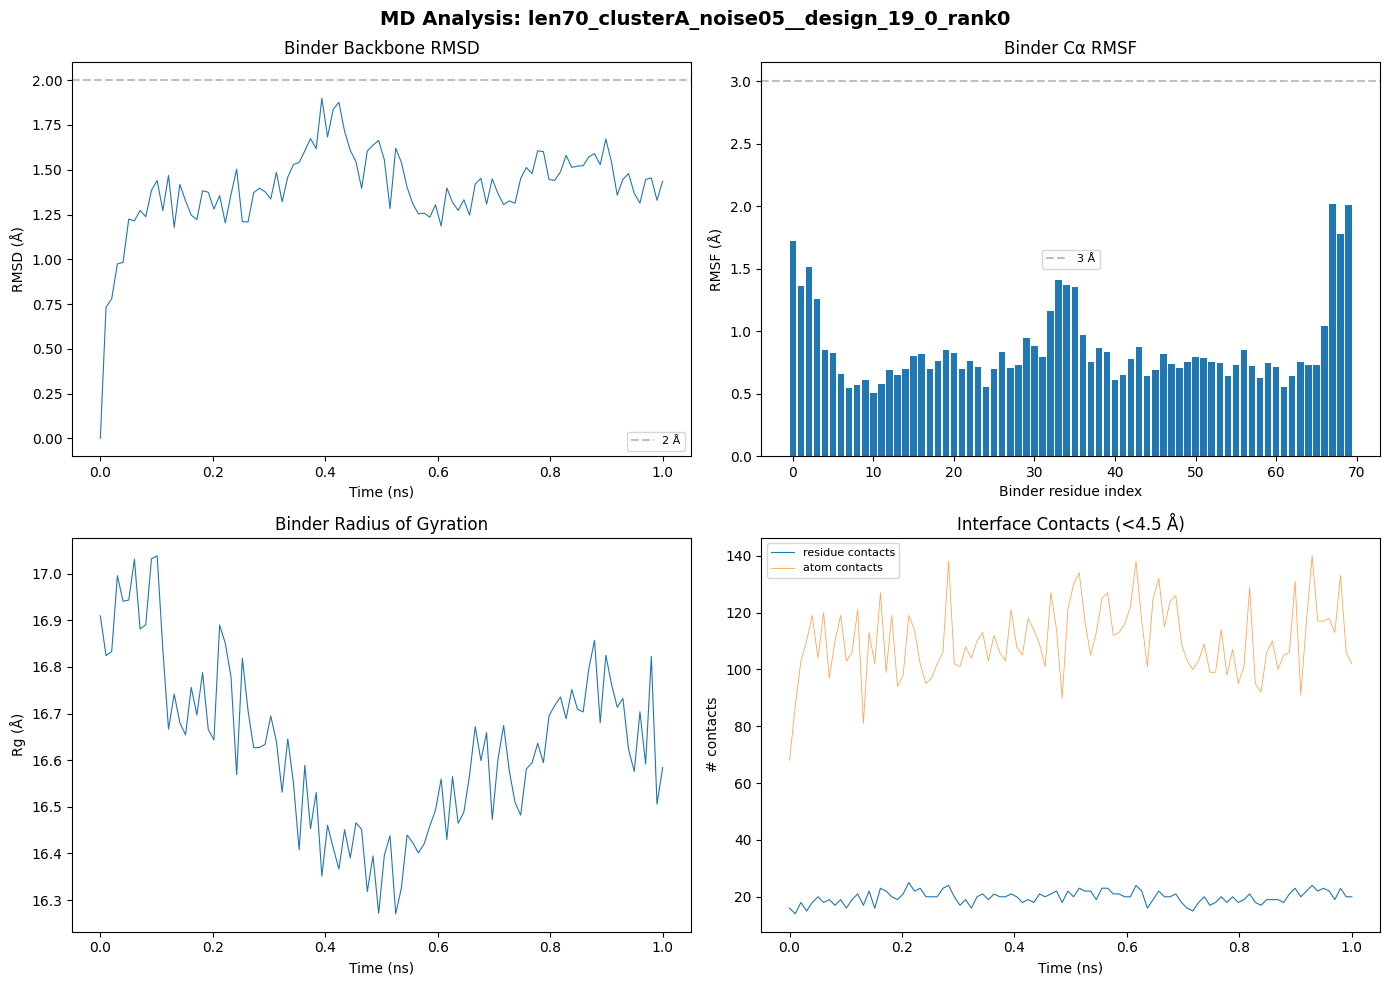

  ✓ Analysis plot: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterA_noise05__design_19_0_rank0/md_analysis.png
  ✓ Metrics CSV: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterA_noise05__design_19_0_rank0/analysis_metrics.csv
  ✓ Summary JSON: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterA_noise05__design_19_0_rank0/md_summary.json

Analyzing: len70_distributed_noise0__design_17_0_rank1
  Frames: 100
  Protein atoms: 2728
  Chain lengths: {0: 70, 1: 115}
  Inferred target chain: 1
  Inferred binder chain: 0
  Binder sequence from topology chain B: AACAALRAAAAATAAAAAAAVAAEAAEAAAECAADPAKCATYQAMAARLAANADRAVAVVAAQTAAACAA
  Binder RMSD: mean=1.93 Å; final=2.83 Å
  Binder heavy atoms: 438
  Target heavy atoms: 922
  Cross-interface atom pairs tested: 403836
  Residue conta

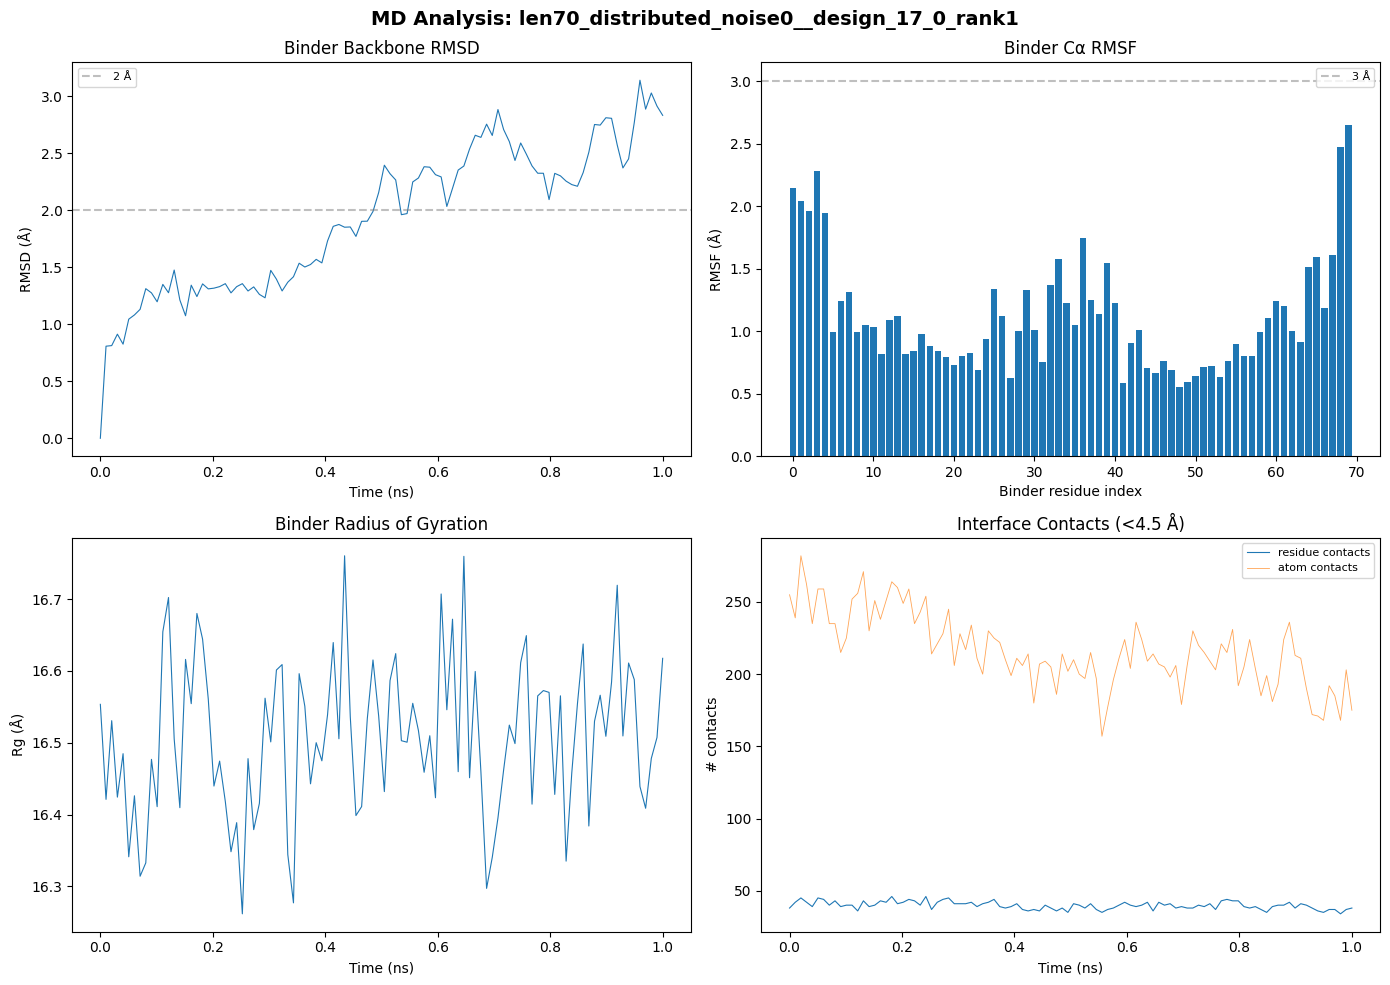

  ✓ Analysis plot: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_distributed_noise0__design_17_0_rank1/md_analysis.png
  ✓ Metrics CSV: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_distributed_noise0__design_17_0_rank1/analysis_metrics.csv
  ✓ Summary JSON: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_distributed_noise0__design_17_0_rank1/md_summary.json

Analyzing: len70_clusterB_noise0__design_19_0_rank1
  Frames: 100
  Protein atoms: 2849
  Chain lengths: {0: 70, 1: 115}
  Inferred target chain: 1
  Inferred binder chain: 0
  Binder sequence from topology chain B: AEEAAATTAQCVAIGQQAFQQMRAISKAAVAAAKASKSAEEAKAILEKADAEIKAIAAQASAQIAALRAA
  Binder RMSD: mean=1.49 Å; final=1.45 Å
  Binder heavy atoms: 487
  Target heavy atoms: 922
  Cross-interface atom pairs tested: 449014
  Residue co

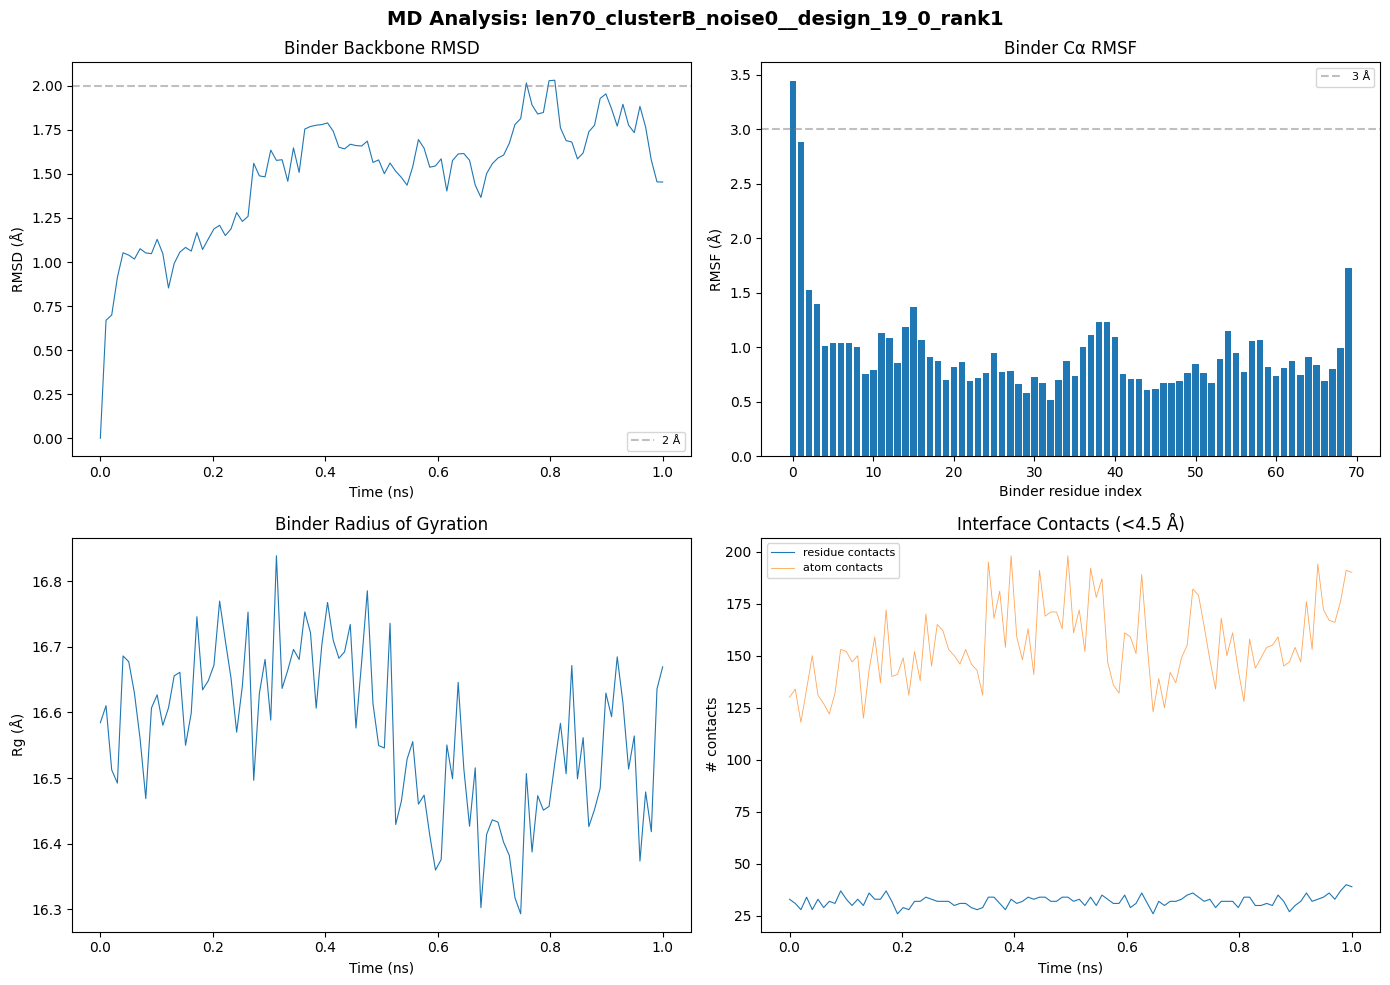

  ✓ Analysis plot: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterB_noise0__design_19_0_rank1/md_analysis.png
  ✓ Metrics CSV: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterB_noise0__design_19_0_rank1/analysis_metrics.csv
  ✓ Summary JSON: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterB_noise0__design_19_0_rank1/md_summary.json
✓ Manifest saved: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/md_manifest.csv (3 rows)


,design_name,condition_id,seq_id,hotspot_config,candidate_class,input_pdb,threaded_complex_pdb,pose_pdb,sequence_source,sequence_source_type,...,production_final_state,production_ns,production_dt_ps,binder_chain,target_chain,binder_sequence,binder_sequence_from_pdb,binder_is_poly_g,mean_plddt,rmsd
0,len70_clusterA_noise05__design_19_0_rank0,len70_clusterA_noise05,design_19_0_rank0,clusterA,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,/content/drive/Othercomputers/My Mac/pdl1-mini...,1,0.001,B,A,EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAALAAEAA...,EAALRAQLLAARAAAQALAAELAALRAAAAAEKDPARKAALAAEAA...,False,94.56,0.24
1,len70_distributed_noise0__design_17_0_rank1,len70_distributed_noise0,design_17_0_rank1,distributed,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,/content/drive/Othercomputers/My Mac/pdl1-mini...,1,0.001,B,A,AACAALRAAAAATAAAAAAAVAAEAAEAAAECAADPAKCATYQAMA...,AACAALRAAAAATAAAAAAAVAAEAAEAAAECAADPAKCATYQAMA...,False,94.33,0.33
2,len70_clusterB_noise0__design_19_0_rank1,len70_clusterB_noise0,design_19_0_rank1,clusterB,sequence_threaded_complex,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...,predicted_pdb,...,/content/drive/Othercomputers/My Mac/pdl1-mini...,1,0.001,B,A,AEEAAATTAQCVAIGQQAFQQMRAISKAAVAAAKASKSAEEAKAIL...,AEEAAATTAQCVAIGQQAFQQMRAISKAAVAAAKASKSAEEAKAIL...,False,93.97,0.44


In [ ]:
def analyze_trajectory(system_info, force=FORCE_ANALYSIS):
    design_name = system_info["design_name"]
    drive_dir = Path(system_info["drive_dir"])
    work_dir = Path(system_info.get("work_dir", drive_dir))
    drive_dir.mkdir(parents=True, exist_ok=True)

    traj_dcd = Path(system_info["traj_dcd"])
    top_pdb = Path(system_info["equilibrated_pdb"])
    metrics_csv = drive_dir / "analysis_metrics.csv"
    contact_csv = drive_dir / "contact_counts.csv"
    plot_png = drive_dir / "md_analysis.png"
    summary_json = drive_dir / "md_summary.json"

    if summary_json.exists() and not force:
        with open(summary_json) as f:
            analysis = json.load(f)
        system_info["analysis"] = analysis
        print(f"✓ Analysis skipped for {design_name}; loaded {summary_json}")
        return system_info

    print(f"\n{'=' * 60}")
    print(f"Analyzing: {design_name}")
    print(f"{'=' * 60}")

    if not traj_dcd.exists():
        raise FileNotFoundError(f"Trajectory missing: {traj_dcd}")
    if not top_pdb.exists():
        raise FileNotFoundError(f"Topology PDB missing: {top_pdb}")

    traj = md.load(str(traj_dcd), top=str(top_pdb))
    protein_atoms = traj.topology.select("protein")
    traj_protein = traj.atom_slice(protein_atoms)

    chains = list(traj_protein.topology.chains)
    chain_lengths = {c.index: len(list(c.residues)) for c in chains}
    binder_chain = min(chain_lengths, key=chain_lengths.get)
    target_chain = max(chain_lengths, key=chain_lengths.get)

    print(f"  Frames: {traj.n_frames}")
    print(f"  Protein atoms: {traj_protein.n_atoms}")
    print(f"  Chain lengths: {chain_lengths}")
    print(f"  Inferred target chain: {target_chain}")
    print(f"  Inferred binder chain: {binder_chain}")

    # Sequence sanity check from topology PDB.
    seqs = extract_chain_sequences_from_pdb(top_pdb)
    # MDTraj chain indices may not equal PDB chain IDs, but order is usually preserved.
    pdb_chain_ids = list(seqs.keys())
    if len(pdb_chain_ids) == len(chains):
        binder_pdb_chain = pdb_chain_ids[binder_chain]
        binder_seq = seqs[binder_pdb_chain]
        print(f"  Binder sequence from topology chain {binder_pdb_chain}: {binder_seq}")
        if is_poly_gly(binder_seq):
            print("  WARNING: analyzed binder sequence is poly-G")

    prod_ns = float(system_info.get("production_ns", PRODUCTION_NS))
    t_ns = np.linspace(0, prod_ns, traj_protein.n_frames)
    results = {
        "design_name": design_name,
        "n_frames": int(traj_protein.n_frames),
        "production_ns": prod_ns,
        "binder_chain": int(binder_chain),
        "target_chain": int(target_chain),
        "binder_n_residues": int(chain_lengths[binder_chain]),
        "target_n_residues": int(chain_lengths[target_chain]),
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"MD Analysis: {design_name}", fontsize=14, fontweight="bold")

    # 1. Binder backbone RMSD, aligned on binder itself. Fold-internal stability.
    binder_bb = traj_protein.topology.select(f"chainid {binder_chain} and backbone")
    binder_ca = traj_protein.topology.select(f"chainid {binder_chain} and name CA")
    if len(binder_bb) > 0:
        traj_bb = traj_protein.atom_slice(binder_bb)
        rmsd = md.rmsd(traj_bb, traj_bb, frame=0) * 10.0
        axes[0, 0].plot(t_ns, rmsd, lw=0.8)
        axes[0, 0].axhline(2.0, color="gray", ls="--", alpha=0.5, label="2 Å")
        axes[0, 0].set(xlabel="Time (ns)", ylabel="RMSD (Å)", title="Binder Backbone RMSD")
        axes[0, 0].legend(fontsize=8)
        results["binder_rmsd_mean"] = float(np.mean(rmsd))
        results["binder_rmsd_final"] = float(rmsd[-1])
        print(f"  Binder RMSD: mean={np.mean(rmsd):.2f} Å; final={rmsd[-1]:.2f} Å")
    else:
        rmsd = np.full(traj_protein.n_frames, np.nan)

    # 2. Binder C-alpha RMSF.
    if len(binder_ca) > 0:
        traj_ca = traj_protein.atom_slice(binder_ca)
        traj_ca.superpose(traj_ca, 0)
        xyz = traj_ca.xyz
        mean_xyz = xyz.mean(axis=0)
        rmsf = np.sqrt(((xyz - mean_xyz) ** 2).sum(axis=2).mean(axis=0)) * 10.0
        axes[0, 1].bar(np.arange(len(rmsf)), rmsf, width=0.8)
        axes[0, 1].axhline(3.0, color="gray", ls="--", alpha=0.5, label="3 Å")
        axes[0, 1].set(xlabel="Binder residue index", ylabel="RMSF (Å)", title="Binder Cα RMSF")
        axes[0, 1].legend(fontsize=8)
        results["binder_rmsf_mean"] = float(np.mean(rmsf))
        results["binder_rmsf_max"] = float(np.max(rmsf))
    else:
        rmsf = np.array([])

    # 3. Binder radius of gyration.
    binder_atoms = traj_protein.topology.select(f"chainid {binder_chain}")
    if len(binder_atoms) > 0:
        traj_binder = traj_protein.atom_slice(binder_atoms)
        rg = md.compute_rg(traj_binder) * 10.0
        axes[1, 0].plot(t_ns, rg, lw=0.8)
        axes[1, 0].set(xlabel="Time (ns)", ylabel="Rg (Å)", title="Binder Radius of Gyration")
        results["binder_rg_mean"] = float(np.mean(rg))
        results["binder_rg_std"] = float(np.std(rg))
        results["binder_rg_final"] = float(rg[-1])
    else:
        rg = np.full(traj_protein.n_frames, np.nan)

    # 4. Explicit target-binder heavy atom contacts.
    contact_cutoff_nm = 0.45  # 4.5 Å
    binder_heavy = traj_protein.topology.select(f"chainid {binder_chain} and not element H")
    target_heavy = traj_protein.topology.select(f"chainid {target_chain} and not element H")
    atom_pairs = np.array([(i, j) for i in binder_heavy for j in target_heavy], dtype=int)
    print(f"  Binder heavy atoms: {len(binder_heavy)}")
    print(f"  Target heavy atoms: {len(target_heavy)}")
    print(f"  Cross-interface atom pairs tested: {len(atom_pairs)}")

    if len(atom_pairs) > 0:
        distances = md.compute_distances(traj_protein, atom_pairs)
        contacts_atom = (distances < contact_cutoff_nm).sum(axis=1)
        min_dist_A = distances.min(axis=1) * 10.0
    else:
        contacts_atom = np.zeros(traj_protein.n_frames, dtype=int)
        min_dist_A = np.full(traj_protein.n_frames, np.nan)

    # Residue-level contacts via closest-heavy distances over explicit residue pairs.
    binder_residues = [r.index for r in traj_protein.topology.residues if r.chain.index == binder_chain]
    target_residues = [r.index for r in traj_protein.topology.residues if r.chain.index == target_chain]
    residue_pairs = np.array([(t, b) for t in target_residues for b in binder_residues], dtype=int)
    if len(residue_pairs) > 0:
        residue_dists, residue_pairs_out = md.compute_contacts(
            traj_protein,
            contacts=residue_pairs,
            scheme="closest-heavy",
        )
        contacts_residue = (residue_dists < contact_cutoff_nm).sum(axis=1)
    else:
        contacts_residue = np.zeros(traj_protein.n_frames, dtype=int)

    axes[1, 1].plot(t_ns, contacts_residue, label="residue contacts", lw=0.8)
    axes[1, 1].plot(t_ns, contacts_atom, label="atom contacts", lw=0.6, alpha=0.7)
    axes[1, 1].set(xlabel="Time (ns)", ylabel="# contacts", title="Interface Contacts (<4.5 Å)")
    axes[1, 1].legend(fontsize=8)

    results.update({
        "contacts_mean": float(np.mean(contacts_residue)),
        "contacts_initial": int(contacts_residue[0]),
        "contacts_final": int(contacts_residue[-1]),
        "contacts_atom_mean": float(np.mean(contacts_atom)),
        "contacts_atom_initial": int(contacts_atom[0]),
        "contacts_atom_final": int(contacts_atom[-1]),
        "min_interface_distance_initial_A": float(min_dist_A[0]),
        "min_interface_distance_final_A": float(min_dist_A[-1]),
        "min_interface_distance_mean_A": float(np.nanmean(min_dist_A)),
        "min_interface_distance_min_A": float(np.nanmin(min_dist_A)),
    })

    print(f"  Residue contacts: mean={results['contacts_mean']:.1f}; initial={results['contacts_initial']}; final={results['contacts_final']}")
    print(f"  Atom contacts: mean={results['contacts_atom_mean']:.1f}; initial={results['contacts_atom_initial']}; final={results['contacts_atom_final']}")
    print(f"  Min interface distance: initial={results['min_interface_distance_initial_A']:.2f} Å; final={results['min_interface_distance_final_A']:.2f} Å; min={results['min_interface_distance_min_A']:.2f} Å")

    plt.tight_layout()
    plt.savefig(plot_png, dpi=200, bbox_inches="tight")
    plt.show()

    df_metrics = pd.DataFrame({
        "time_ns": t_ns,
        "binder_rmsd_A": rmsd,
        "binder_rg_A": rg,
        "residue_contacts_lt_4p5A": contacts_residue,
        "atom_contacts_lt_4p5A": contacts_atom,
        "min_interface_distance_A": min_dist_A,
    })
    df_metrics.to_csv(metrics_csv, index=False)
    pd.DataFrame({"time_ns": t_ns, "residue_contacts": contacts_residue, "atom_contacts": contacts_atom}).to_csv(contact_csv, index=False)

    with open(summary_json, "w") as f:
        json.dump(results, f, indent=2)

    system_info["analysis"] = results
    print(f"  ✓ Analysis plot: {plot_png}")
    print(f"  ✓ Metrics CSV: {metrics_csv}")
    print(f"  ✓ Summary JSON: {summary_json}")
    return system_info

# Analyze only systems that have trajectories.
for i, s in enumerate(prepared_systems):
    if s.get("traj_dcd") and Path(s["traj_dcd"]).exists():
        prepared_systems[i] = analyze_trajectory(s)
    else:
        print(f"Skipping analysis for {s.get('design_name')}: no trajectory found")

save_manifest(prepared_systems)


## Cell 11 — Summary table and metadata export


In [ ]:
rows = []
for s in prepared_systems:
    r = s.get("analysis")
    # If analysis not in RAM, load from summary JSON if available.
    if not r:
        sj = Path(s.get("drive_dir", "")) / "md_summary.json"
        if sj.exists():
            with open(sj) as f:
                r = json.load(f)
            s["analysis"] = r
        else:
            r = {}
    rows.append({
        "design": s.get("design_name"),
        "candidate_class": s.get("candidate_class"),
        "binder_is_poly_g": s.get("binder_is_poly_g"),
        "binder_n_residues": r.get("binder_n_residues"),
        "target_n_residues": r.get("target_n_residues"),
        "rmsd_mean_A": r.get("binder_rmsd_mean"),
        "rmsd_final_A": r.get("binder_rmsd_final"),
        "rmsf_mean_A": r.get("binder_rmsf_mean"),
        "rmsf_max_A": r.get("binder_rmsf_max"),
        "rg_mean_A": r.get("binder_rg_mean"),
        "rg_std_A": r.get("binder_rg_std"),
        "contacts_mean": r.get("contacts_mean"),
        "contacts_initial": r.get("contacts_initial"),
        "contacts_final": r.get("contacts_final"),
        "atom_contacts_mean": r.get("contacts_atom_mean"),
        "min_interface_distance_mean_A": r.get("min_interface_distance_mean_A"),
        "min_interface_distance_final_A": r.get("min_interface_distance_final_A"),
        "production_ns": s.get("production_ns"),
        "production_dt_ps": s.get("production_dt_ps"),
        "input_pdb": s.get("input_pdb"),
        "traj_dcd": s.get("traj_dcd"),
    })

df_summary = pd.DataFrame(rows)
print("=== MD Simulation Summary ===")
display(df_summary)

df_summary.to_csv(SUMMARY_PATH, index=False)

meta = {
    "production_ns": PRODUCTION_NS,
    "production_dt_ps": PRODUCTION_DT_PS,
    "force_field": "amber14-all.xml + amber14/tip3p.xml",

    "temperature_K": TEMPERATURE_K,
    "pressure_bar": PRESSURE_BAR,
    "ionic_strength_M": IONIC_STRENGTH_M,
    "solvent_padding_nm": SOLVENT_PADDING_NM,
    "platform_name": PLATFORM_NAME,
    "allow_poly_g_inputs": ALLOW_POLY_G_INPUTS,
    "notes": "Restart-safe notebook. Sequence-bearing PDB validation rejects RFdiffusion poly-G backbones unless explicitly allowed. Initial production runs used tip3pfb.xml forcefield with tip3p water geometry; corrected to consistent amber14/tip3p.xml. Restraint energy expression corrected to include 0.5 factor for standard harmonic convention.",

}
with open(METADATA_PATH, "w") as f:
    json.dump(meta, f, indent=2)

save_manifest(prepared_systems)
print(f"\n✓ Summary saved: {SUMMARY_PATH}")
print(f"✓ Metadata saved: {METADATA_PATH}")


=== MD Simulation Summary ===


,design,candidate_class,binder_is_poly_g,binder_n_residues,target_n_residues,rmsd_mean_A,rmsd_final_A,rmsf_mean_A,rmsf_max_A,rg_mean_A,...,contacts_mean,contacts_initial,contacts_final,atom_contacts_mean,min_interface_distance_mean_A,min_interface_distance_final_A,production_ns,production_dt_ps,input_pdb,traj_dcd
0,len70_clusterA_noise05__design_19_0_rank0,sequence_threaded_complex,False,70,115,1.395871,1.436675,0.863282,2.016432,16.628966,...,19.85,16,20,110.20,2.747763,2.831217,1,0.001,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...
1,len70_distributed_noise0__design_17_0_rank1,sequence_threaded_complex,False,70,115,1.928165,2.833703,1.119986,2.648595,16.506797,...,39.83,38,38,216.45,2.668928,2.774052,1,0.001,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...
2,len70_clusterB_noise0__design_19_0_rank1,sequence_threaded_complex,False,70,115,1.490639,1.453929,0.954726,3.440869,16.570177,...,32.16,33,39,154.91,2.692054,2.619351,1,0.001,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...


✓ Manifest saved: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/md_manifest.csv (3 rows)

✓ Summary saved: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/md_simulation_summary.csv
✓ Metadata saved: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/md_metadata.json


## Cell 12 — Quick log inspection helper

Run this after production to verify temperature, density, energy, and speed.


In [ ]:
for s in prepared_systems:
    log_path = Path(s.get("production_log", ""))
    print("\n", s.get("design_name"))
    if log_path.exists():
        df_log = pd.read_csv(log_path)
        display(df_log.tail())
    else:
        print("  No production log found")



 len70_clusterA_noise05__design_19_0_rank0


,"#""Step""",Time (ps),Potential Energy (kJ/mole),Temperature (K),Box Volume (nm^3),Density (g/mL),Speed (ns/day),Time Remaining
95,970000,970.0,-1.084907e+06,300.262169,649.705726,1.011927,28.6,1:30
96,980000,980.0,-1.085098e+06,299.222537,647.743180,1.014993,28.6,1:00
97,990000,990.0,-1.086157e+06,299.294343,645.701568,1.018203,28.6,0:30
98,1000000,1000.0,-1.085718e+06,299.530893,649.103115,1.012867,28.6,0:00
99,1010000,1010.0,-1.085538e+06,299.842474,648.150244,1.014356,28.6,23:59:30



 len70_distributed_noise0__design_17_0_rank1


,"#""Step""",Time (ps),Potential Energy (kJ/mole),Temperature (K),Box Volume (nm^3),Density (g/mL),Speed (ns/day),Time Remaining
95,970000,970.0,-727489.009003,301.876558,439.347956,1.020776,42.9,1:00
96,980000,980.0,-728273.903433,300.602663,438.483924,1.022787,42.9,0:40
97,990000,990.0,-727781.832093,300.946533,440.783780,1.017451,42.9,0:20
98,1000000,1000.0,-727688.539805,296.802247,439.353599,1.020763,42.9,0:00
99,1010000,1010.0,-728387.685893,299.569850,438.510259,1.022726,42.9,23:59:40



 len70_clusterB_noise0__design_19_0_rank1


,"#""Step""",Time (ps),Potential Energy (kJ/mole),Temperature (K),Box Volume (nm^3),Density (g/mL),Speed (ns/day),Time Remaining
95,970000,970.0,-791038.166626,300.353278,477.062101,1.019554,40.1,1:04
96,980000,980.0,-790637.202657,297.863177,477.436595,1.018754,40.1,0:43
97,990000,990.0,-791055.861526,302.660069,475.892039,1.022061,40.1,0:21
98,1000000,1000.0,-790033.111291,300.300767,477.302538,1.019041,40.1,0:00
99,1010000,1010.0,-791399.228883,299.119250,476.764178,1.020191,40.1,23:59:39


## Cell 13: Trajectory animation viewer

In [ ]:
# ============================================================
# Trajectory animation viewer — explicit target-aligned PDB writer
# ============================================================
#
# This version is for visualization only.
# It explicitly:
#   1. loads the protein-only trajectory
#   2. moves the binder to the nearest periodic image relative to the target
#   3. aligns every frame on target-chain CA atoms using Kabsch alignment
#   4. writes a multi-model PDB manually
#
# This avoids target/binder jumping artifacts in py3Dmol.

!pip install -q py3Dmol mdtraj

import numpy as np
import mdtraj as md
import py3Dmol
from pathlib import Path


def get_chain_index_by_chain_id_or_length(topology, chain_id=None, role=None):
    """
    Resolve an MDTraj chain index.

    First tries PDB chain ID, e.g. A/B.
    If that fails:
      - role='binder' -> shortest chain
      - role='target' -> longest chain
    """

    chains = list(topology.chains)

    if chain_id is not None:
        for chain in chains:
            if chain.chain_id == chain_id:
                return chain.index

    chain_lengths = {
        chain.index: len(list(chain.residues))
        for chain in chains
    }

    if role == "binder":
        return min(chain_lengths, key=chain_lengths.get)

    if role == "target":
        return max(chain_lengths, key=chain_lengths.get)

    raise ValueError(
        f"Could not resolve chain_id={chain_id}; "
        f"available chain IDs={[c.chain_id for c in chains]}"
    )


def kabsch_align_mobile_to_reference(mobile, reference):
    """
    Return rotation matrix R and translation vectors to align mobile -> reference.

    mobile, reference: arrays with shape (n_atoms, 3), in nm.

    Output:
        aligned = (coords - mobile_centroid) @ R + reference_centroid
    """

    mobile_centroid = mobile.mean(axis=0)
    reference_centroid = reference.mean(axis=0)

    mobile_centered = mobile - mobile_centroid
    reference_centered = reference - reference_centroid

    covariance = mobile_centered.T @ reference_centered

    V, S, Wt = np.linalg.svd(covariance)

    d = np.sign(np.linalg.det(V @ Wt))
    D = np.diag([1.0, 1.0, d])

    R = V @ D @ Wt

    return R, mobile_centroid, reference_centroid


def write_multimodel_pdb_from_traj(traj, out_pdb):
    """
    Manually write a multi-model PDB from an MDTraj trajectory.

    Coordinates are converted from nm to Å.
    """

    out_pdb = Path(out_pdb)

    with open(out_pdb, "w") as f:
        for frame_idx in range(traj.n_frames):
            f.write(f"MODEL     {frame_idx + 1:4d}\n")

            xyz_A = traj.xyz[frame_idx] * 10.0  # nm -> Å

            for atom_serial, atom in enumerate(traj.topology.atoms, start=1):
                residue = atom.residue
                chain = residue.chain

                atom_name = atom.name
                resname = residue.name
                chain_id = chain.chain_id if chain.chain_id else chr(65 + chain.index)
                resseq = residue.resSeq if residue.resSeq is not None else residue.index + 1
                element = atom.element.symbol if atom.element is not None else atom_name[0]

                x, y, z = xyz_A[atom.index]

                # PDB ATOM formatting
                f.write(
                    f"ATOM  {atom_serial:5d} "
                    f"{atom_name:<4s}"
                    f" "
                    f"{resname:>3s} "
                    f"{chain_id:1s}"
                    f"{resseq:4d}"
                    f"    "
                    f"{x:8.3f}{y:8.3f}{z:8.3f}"
                    f"  1.00  0.00"
                    f"          "
                    f"{element:>2s}"
                    f"\n"
                )

            f.write("ENDMDL\n")

        f.write("END\n")

    return out_pdb


def make_target_locked_visualization_pdb(system_info, max_frames=100, stride=None):
    """
    Build a target-locked, PBC-corrected protein-only multi-model PDB.

    This is the file py3Dmol should animate.
    """

    design_name = system_info["design_name"]

    traj_path = Path(system_info["traj_dcd"])
    top_path = Path(system_info["equilibrated_pdb"])

    target_chain_id = system_info.get("target_chain", "A")
    binder_chain_id = system_info.get("binder_chain", "B")

    print(f"\nPreparing target-locked visualization trajectory: {design_name}")
    print(f"  traj: {traj_path}")
    print(f"  top:  {top_path}")
    print(f"  target_chain_id: {target_chain_id}")
    print(f"  binder_chain_id: {binder_chain_id}")

    traj_full = md.load(str(traj_path), top=str(top_path))

    # Protein-only trajectory
    protein_atoms = traj_full.topology.select("protein")
    traj = traj_full.atom_slice(protein_atoms)

    target_chain_idx = get_chain_index_by_chain_id_or_length(
        traj.topology,
        chain_id=target_chain_id,
        role="target",
    )

    binder_chain_idx = get_chain_index_by_chain_id_or_length(
        traj.topology,
        chain_id=binder_chain_id,
        role="binder",
    )

    target_atoms = traj.topology.select(f"chainid {target_chain_idx} and protein")
    binder_atoms = traj.topology.select(f"chainid {binder_chain_idx} and protein")
    target_ca = traj.topology.select(f"chainid {target_chain_idx} and name CA")

    print(f"  target_chain_idx: {target_chain_idx}")
    print(f"  binder_chain_idx: {binder_chain_idx}")
    print(f"  target atoms: {len(target_atoms)}")
    print(f"  binder atoms: {len(binder_atoms)}")
    print(f"  target CA atoms for alignment: {len(target_ca)}")

    if len(target_ca) < 3:
        raise ValueError("Need at least 3 target CA atoms for alignment")

    xyz = traj.xyz.copy()

    # --------------------------------------------------------
    # Step 1: move binder to nearest periodic image of target
    # --------------------------------------------------------

    if traj.unitcell_lengths is not None:
        for frame_idx in range(traj.n_frames):
            box = traj.unitcell_lengths[frame_idx]  # nm

            target_com = xyz[frame_idx, target_atoms, :].mean(axis=0)
            binder_com = xyz[frame_idx, binder_atoms, :].mean(axis=0)

            delta = binder_com - target_com
            shift = -np.round(delta / box) * box

            xyz[frame_idx, binder_atoms, :] += shift

        print("  ✓ Binder reimaged near target using periodic box lengths")
    else:
        print("  Warning: no unitcell lengths found; skipped PBC reimaging")

    # --------------------------------------------------------
    # Step 2: align every frame to frame 0 using target CA atoms
    # --------------------------------------------------------

    ref_ca = xyz[0, target_ca, :].copy()

    for frame_idx in range(traj.n_frames):
        mobile_ca = xyz[frame_idx, target_ca, :]

        R, mobile_centroid, reference_centroid = kabsch_align_mobile_to_reference(
            mobile_ca,
            ref_ca,
        )

        xyz[frame_idx, :, :] = (
            (xyz[frame_idx, :, :] - mobile_centroid) @ R + reference_centroid
        )

    print("  ✓ Frames aligned on target-chain CA atoms")

    # --------------------------------------------------------
    # Step 3: translate target center to origin in every frame
    # --------------------------------------------------------

    for frame_idx in range(traj.n_frames):
        target_com = xyz[frame_idx, target_atoms, :].mean(axis=0)
        xyz[frame_idx, :, :] -= target_com

    print("  ✓ Target centered at origin in every frame")

    traj.xyz = xyz

    # Downsample for display
    n_frames = traj.n_frames

    if stride is None:
        stride = max(1, n_frames // max_frames)

    traj_view = traj[::stride]

    out_pdb = Path(system_info["drive_dir"]) / "protein_trajectory_TARGET_LOCKED_for_viewer.pdb"

    write_multimodel_pdb_from_traj(traj_view, out_pdb)

    print(f"  Original frames: {n_frames}")
    print(f"  Display frames:  {traj_view.n_frames}")
    print(f"  Stride:          {stride}")
    print(f"  ✓ Wrote target-locked multi-model PDB: {out_pdb}")

    return out_pdb


def animate_target_locked_complex(system_info, max_frames=100, stride=None, width=900, height=650):
    """
    Animate the target-locked visualization PDB in py3Dmol.
    """

    design_name = system_info["design_name"]
    target_chain = system_info.get("target_chain", "A")
    binder_chain = system_info.get("binder_chain", "B")

    pdb_path = make_target_locked_visualization_pdb(
        system_info,
        max_frames=max_frames,
        stride=stride,
    )

    pdb_text = Path(pdb_path).read_text()

    print(f"\nAnimating target-locked trajectory: {design_name}")
    print(f"  Target chain: {target_chain}")
    print(f"  Binder chain: {binder_chain}")
    print(f"  Viewer PDB: {pdb_path}")

    view = py3Dmol.view(width=width, height=height)
    view.addModelsAsFrames(pdb_text)

    view.setStyle({}, {})

    view.setStyle(
        {"chain": target_chain},
        {
            "cartoon": {
                "color": "lightgray",
                "opacity": 0.9,
            }
        },
    )

    view.setStyle(
        {"chain": binder_chain},
        {
            "cartoon": {
                "color": "royalblue",
                "opacity": 1.0,
            }
        },
    )

    # Binder residues near target
    view.addStyle(
        {
            "chain": binder_chain,
            "within": {
                "distance": 5.0,
                "sel": {"chain": target_chain},
            },
        },
        {
            "stick": {
                "radius": 0.18,
                "color": "orange",
            }
        },
    )

    # Target residues near binder
    view.addStyle(
        {
            "chain": target_chain,
            "within": {
                "distance": 5.0,
                "sel": {"chain": binder_chain},
            },
        },
        {
            "stick": {
                "radius": 0.12,
                "color": "darkgray",
            }
        },
    )

    view.zoomTo({"chain": target_chain})
    view.zoom(1.3)

    view.animate(
        {
            "loop": "forward",
            "reps": 0,
            "interval": 100,
        }
    )

    return view.show()

In [ ]:
animate_target_locked_complex(prepared_systems[2], max_frames=100)

Output hidden; open in https://colab.research.google.com to view.

## Cell 14: Pair interaction heatmap



Extracting interface pairs: len70_clusterA_noise05__design_19_0_rank0
  Trajectory: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterA_noise05__design_19_0_rank0/production.dcd
  Topology:   /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterA_noise05__design_19_0_rank0/equilibrated.pdb
  Target chain: A
  Binder chain: B
  Frames: 100
  Frame interval: 1.00 ps
  Binder residues: 70
  Target residues: 115
  Residue pairs tested: 8050
  Nonzero-contact pairs: 38
  ✓ Pair persistence CSV: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterA_noise05__design_19_0_rank0/interface_pair_persistence.csv
  ✓ Nonzero pairs CSV:    /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterA_noise05__design_19_0_rank0/interfac

,binder_residue,target_residue,pair_class,occupancy,max_residence_ps,mean_residence_ps,min_distance_A,mean_distance_A
0,GLN16,ALA121,candidate_polar_hbond,1.00,100.0,100.000000,2.615319,2.871639
1,ARG5,GLN47,candidate_polar_hbond,1.00,100.0,100.000000,2.637050,2.932586
2,GLN16,GLY120,candidate_polar_hbond,1.00,100.0,100.000000,2.933847,3.429160
3,ARG5,ASP49,candidate_salt_bridge,1.00,100.0,100.000000,3.017133,3.510058
4,LEU9,TYR118,candidate_polar_hbond,1.00,100.0,100.000000,3.037846,3.480649
5,LEU9,GLY119,other_contact,1.00,100.0,100.000000,3.067710,3.608574
6,LEU9,ALA52,candidate_hydrophobic,1.00,100.0,100.000000,3.132640,3.723287
7,ALA6,ASP49,other_contact,0.99,99.0,99.000000,2.764931,3.440560
8,ARG12,GLU45,candidate_salt_bridge,0.99,90.0,49.500000,2.569050,2.850142
9,ARG12,GLY119,other_contact,0.99,63.0,49.500000,3.162803,3.767684


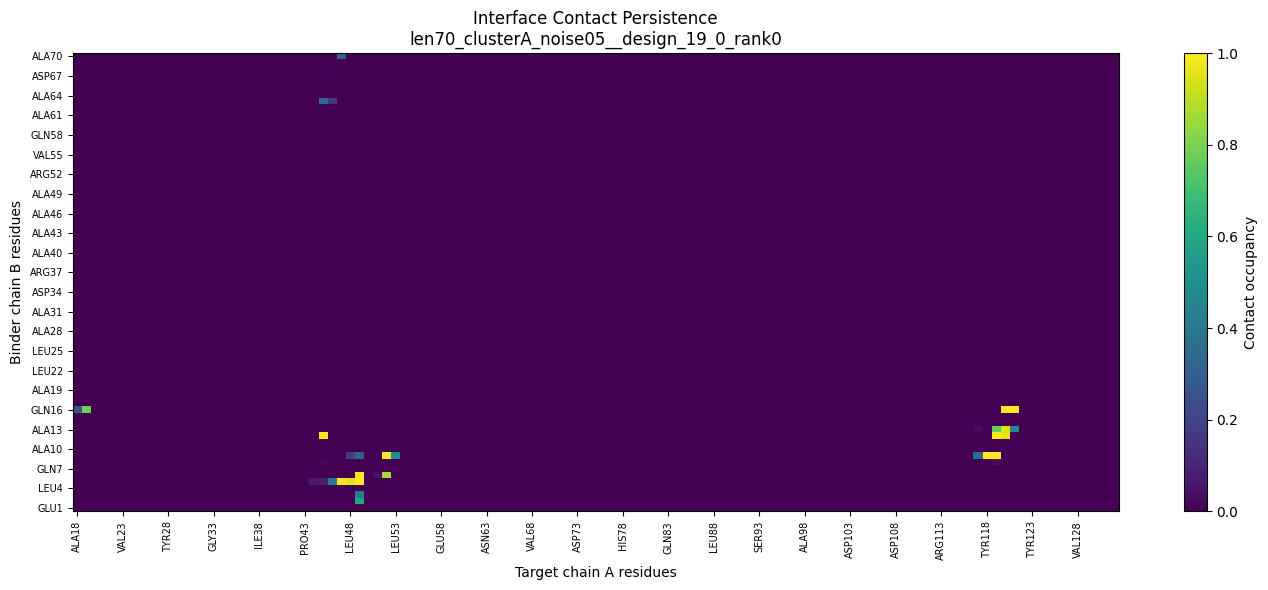

  ✓ Heatmap saved: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterA_noise05__design_19_0_rank0/interface_contact_persistence_heatmap.png

Extracting interface pairs: len70_distributed_noise0__design_17_0_rank1
  Trajectory: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_distributed_noise0__design_17_0_rank1/production.dcd
  Topology:   /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_distributed_noise0__design_17_0_rank1/equilibrated.pdb
  Target chain: A
  Binder chain: B
  Frames: 100
  Frame interval: 1.00 ps
  Binder residues: 70
  Target residues: 115
  Residue pairs tested: 8050
  Nonzero-contact pairs: 71
  ✓ Pair persistence CSV: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_distributed_noise0__design_17_0_ra

,binder_residue,target_residue,pair_class,occupancy,max_residence_ps,mean_residence_ps,min_distance_A,mean_distance_A
0,ASN52,TYR56,candidate_polar_hbond,1.00,100.0,100.000000,2.467210,2.915524
1,GLU24,ARG113,candidate_salt_bridge,1.00,100.0,100.000000,2.570917,2.732080
2,GLU24,ARG125,candidate_salt_bridge,1.00,100.0,100.000000,2.616137,2.772883
3,ARG55,ASP73,candidate_salt_bridge,1.00,100.0,100.000000,2.620668,2.784441
4,ASN52,ASN63,candidate_polar_hbond,1.00,100.0,100.000000,2.635758,2.835938
5,MET45,ARG113,other_contact,1.00,100.0,100.000000,2.840947,3.318676
6,LEU49,TYR123,candidate_polar_hbond,1.00,100.0,100.000000,2.850195,3.594133
7,ALA16,ALA121,candidate_hydrophobic,1.00,100.0,100.000000,2.861911,3.503344
8,ALA20,ALA121,candidate_hydrophobic,1.00,100.0,100.000000,2.885262,3.426194
9,ALA56,TYR56,candidate_polar_hbond,1.00,100.0,100.000000,2.972025,3.516246


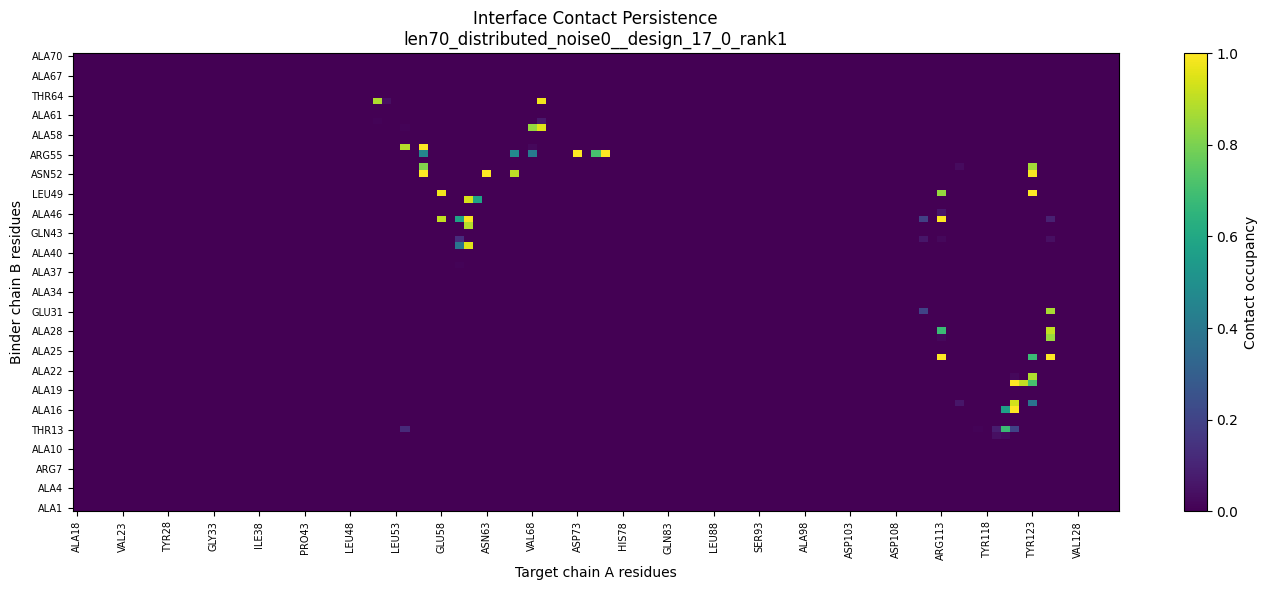

  ✓ Heatmap saved: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_distributed_noise0__design_17_0_rank1/interface_contact_persistence_heatmap.png

Extracting interface pairs: len70_clusterB_noise0__design_19_0_rank1
  Trajectory: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterB_noise0__design_19_0_rank1/production.dcd
  Topology:   /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterB_noise0__design_19_0_rank1/equilibrated.pdb
  Target chain: A
  Binder chain: B
  Frames: 100
  Frame interval: 1.00 ps
  Binder residues: 70
  Target residues: 115
  Residue pairs tested: 8050
  Nonzero-contact pairs: 75
  ✓ Pair persistence CSV: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterB_noise0__design_19_0_rank1/interf

,binder_residue,target_residue,pair_class,occupancy,max_residence_ps,mean_residence_ps,min_distance_A,mean_distance_A
0,SER61,ALA121,candidate_polar_hbond,1.00,100.0,100.000000,2.552984,3.116920
1,SER26,ASP61,candidate_polar_hbond,1.00,100.0,100.000000,2.558116,3.597297
2,ASP50,ARG113,candidate_salt_bridge,1.00,100.0,100.000000,2.607323,2.824062
3,ARG23,ASN63,candidate_polar_hbond,1.00,100.0,100.000000,2.632217,2.966081
4,GLY15,TYR56,candidate_polar_hbond,1.00,100.0,100.000000,2.644758,3.423198
5,ALA57,TYR123,candidate_polar_hbond,1.00,100.0,100.000000,2.937354,3.478404
6,PHE19,TYR56,candidate_aromatic_stacking,1.00,100.0,100.000000,2.944803,3.365706
7,ILE53,ARG113,other_contact,0.99,73.0,49.500000,3.142259,3.661821
8,ILE64,GLY120,other_contact,0.99,61.0,49.500000,3.162982,3.648265
9,VAL30,ASP61,other_contact,0.99,57.0,49.500000,3.081592,3.802011


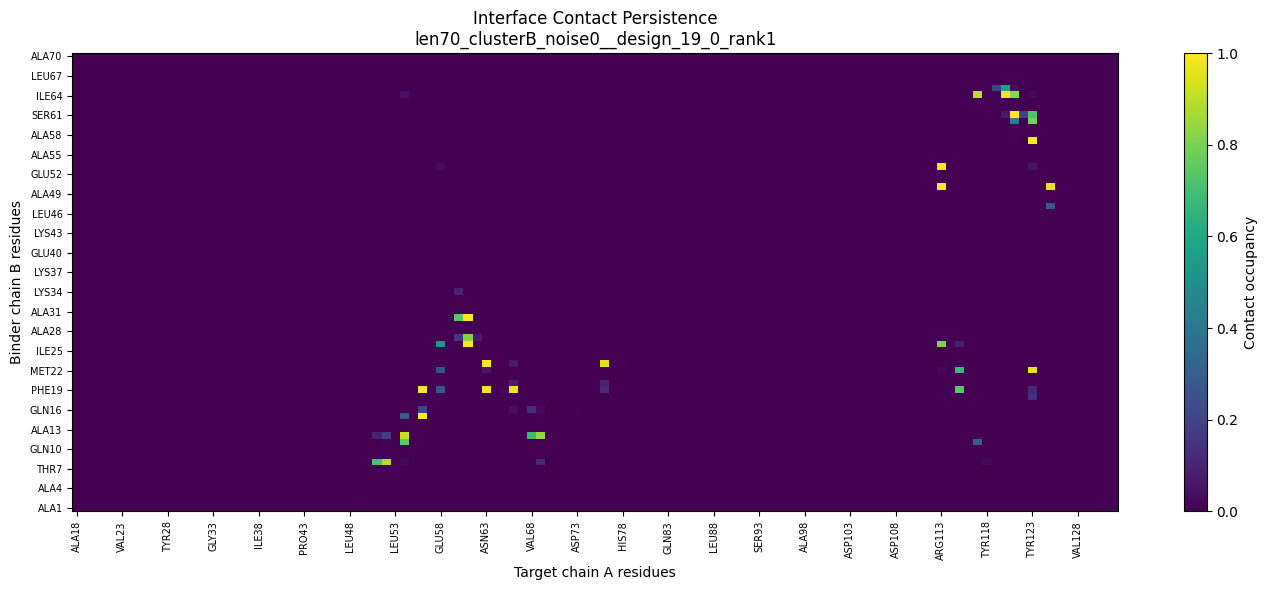

  ✓ Heatmap saved: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/len70_clusterB_noise0__design_19_0_rank1/interface_contact_persistence_heatmap.png
✓ Manifest saved: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/md_manifest.csv (3 rows)

✓ Combined interface pair table saved: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/all_interface_pair_persistence.csv

Top contact pairs across all systems:


,design_name,binder_residue,target_residue,pair_class,occupancy,max_residence_ps,mean_residence_ps,min_distance_A,mean_distance_A
8050,len70_distributed_noise0__design_17_0_rank1,ASN52,TYR56,candidate_polar_hbond,1.00,100.0,100.000000,2.467210,2.915524
16100,len70_clusterB_noise0__design_19_0_rank1,SER61,ALA121,candidate_polar_hbond,1.00,100.0,100.000000,2.552984,3.116920
16101,len70_clusterB_noise0__design_19_0_rank1,SER26,ASP61,candidate_polar_hbond,1.00,100.0,100.000000,2.558116,3.597297
8051,len70_distributed_noise0__design_17_0_rank1,GLU24,ARG113,candidate_salt_bridge,1.00,100.0,100.000000,2.570917,2.732080
16102,len70_clusterB_noise0__design_19_0_rank1,ASP50,ARG113,candidate_salt_bridge,1.00,100.0,100.000000,2.607323,2.824062
0,len70_clusterA_noise05__design_19_0_rank0,GLN16,ALA121,candidate_polar_hbond,1.00,100.0,100.000000,2.615319,2.871639
8052,len70_distributed_noise0__design_17_0_rank1,GLU24,ARG125,candidate_salt_bridge,1.00,100.0,100.000000,2.616137,2.772883
8053,len70_distributed_noise0__design_17_0_rank1,ARG55,ASP73,candidate_salt_bridge,1.00,100.0,100.000000,2.620668,2.784441
16103,len70_clusterB_noise0__design_19_0_rank1,ARG23,ASN63,candidate_polar_hbond,1.00,100.0,100.000000,2.632217,2.966081
8054,len70_distributed_noise0__design_17_0_rank1,ASN52,ASN63,candidate_polar_hbond,1.00,100.0,100.000000,2.635758,2.835938


In [ ]:
# ============================================================
# Cell 14 — Interface pair extraction and contact persistence
# ============================================================
#
# Goal:
#   For each MD trajectory, explicitly identify binder–target residue pairs
#   that contact over time, classify their chemistry, and compute simple
#   "kinetic" contact metrics:
#
#     - occupancy: fraction of frames in contact
#     - n_contact_frames
#     - n_transitions_on
#     - mean residence time
#     - max residence time
#
# This becomes the residue-pair layer for deeper analyses such as:
#   aromatic stacking trajectories
#   salt-bridge residence
#   rotamer-state tracking
#   contact switching

import numpy as np
import pandas as pd
import mdtraj as md
from pathlib import Path
import matplotlib.pyplot as plt


CONTACT_CUTOFF_NM = 0.45   # 4.5 Å residue contact cutoff
TOP_N_CONTACTS = 30        # save/print top persistent pairs


AA_CLASSES = {
    "hydrophobic": {"ALA", "VAL", "LEU", "ILE", "MET", "PHE", "TRP", "PRO"},
    "aromatic": {"PHE", "TYR", "TRP", "HIS"},
    "positive": {"LYS", "ARG", "HIS"},
    "negative": {"ASP", "GLU"},
    "polar": {"SER", "THR", "ASN", "GLN", "TYR", "CYS", "HIS"},
    "special": {"GLY", "PRO", "CYS"},
}


def get_chain_index_from_chain_id(topology, chain_id):
    """
    Convert chain ID such as 'A' or 'B' to MDTraj chain index.
    Falls back to shortest/longest inference only if chain_id is unavailable.
    """
    for chain in topology.chains:
        if chain.chain_id == chain_id:
            return chain.index

    raise ValueError(
        f"Chain ID {chain_id} not found. "
        f"Available chain IDs: {[c.chain_id for c in topology.chains]}"
    )


def residue_label(residue):
    """
    Human-readable residue label.
    Example: TYR45 or ALA12.
    """
    resseq = residue.resSeq if residue.resSeq is not None else residue.index + 1
    return f"{residue.name}{resseq}"


def classify_pair(res1_name, res2_name):
    """
    Coarse interaction class based on residue identity.
    This is not a geometric proof of the interaction type.
    It identifies candidate interaction classes for follow-up geometry tracking.
    """

    r1 = res1_name.upper()
    r2 = res2_name.upper()

    r1_arom = r1 in AA_CLASSES["aromatic"]
    r2_arom = r2 in AA_CLASSES["aromatic"]
    r1_pos = r1 in AA_CLASSES["positive"]
    r2_pos = r2 in AA_CLASSES["positive"]
    r1_neg = r1 in AA_CLASSES["negative"]
    r2_neg = r2 in AA_CLASSES["negative"]
    r1_hyd = r1 in AA_CLASSES["hydrophobic"]
    r2_hyd = r2 in AA_CLASSES["hydrophobic"]
    r1_pol = r1 in AA_CLASSES["polar"]
    r2_pol = r2 in AA_CLASSES["polar"]

    if r1_arom and r2_arom:
        return "candidate_aromatic_stacking"

    if (r1_pos and r2_neg) or (r1_neg and r2_pos):
        return "candidate_salt_bridge"

    if (r1_arom and r2_pos) or (r2_arom and r1_pos):
        return "candidate_cation_pi"

    if r1_hyd and r2_hyd:
        return "candidate_hydrophobic"

    if r1_pol or r2_pol:
        return "candidate_polar_hbond"

    return "other_contact"


def contiguous_true_runs(bool_array):
    """
    Return lengths of contiguous True runs in a boolean array.
    """
    runs = []
    current = 0

    for val in bool_array:
        if val:
            current += 1
        else:
            if current > 0:
                runs.append(current)
                current = 0

    if current > 0:
        runs.append(current)

    return runs


def transition_count_on(bool_array):
    """
    Count False -> True transitions.
    If the first frame is True, count that as one contact-start event.
    """
    arr = np.asarray(bool_array, dtype=bool)

    if len(arr) == 0:
        return 0

    starts = 1 if arr[0] else 0
    starts += np.sum((~arr[:-1]) & (arr[1:]))

    return int(starts)


def infer_frame_interval_ps(traj, system_info):
    """
    Infer trajectory frame spacing in ps.

    MDTraj DCD time metadata is not always populated reliably depending on writer.
    If unavailable, fall back to production_ns / n_frames.
    """
    if traj.n_frames > 1 and traj.time is not None:
        dt = float(np.median(np.diff(traj.time)))
        if np.isfinite(dt) and dt > 0:
            return dt

    production_ns = float(system_info.get("production_ns", 0))
    if production_ns > 0 and traj.n_frames > 1:
        return production_ns * 1000.0 / (traj.n_frames - 1)

    return np.nan


def extract_interface_pair_persistence(system_info, contact_cutoff_nm=CONTACT_CUTOFF_NM):
    """
    Extract binder-target residue pair contact persistence from an MD trajectory.
    """

    design_name = system_info["design_name"]
    traj_path = Path(system_info["traj_dcd"])
    top_path = Path(system_info["equilibrated_pdb"])
    out_dir = Path(system_info["drive_dir"])

    binder_chain_id = system_info.get("binder_chain", "B")
    target_chain_id = system_info.get("target_chain", "A")

    print(f"\n{'=' * 60}")
    print(f"Extracting interface pairs: {design_name}")
    print(f"{'=' * 60}")
    print(f"  Trajectory: {traj_path}")
    print(f"  Topology:   {top_path}")
    print(f"  Target chain: {target_chain_id}")
    print(f"  Binder chain: {binder_chain_id}")

    if not traj_path.exists():
        raise FileNotFoundError(f"Trajectory not found: {traj_path}")

    if not top_path.exists():
        raise FileNotFoundError(f"Topology PDB not found: {top_path}")

    traj = md.load(str(traj_path), top=str(top_path))

    # Protein-only trajectory keeps residue indexing manageable.
    protein_atoms = traj.topology.select("protein")
    traj_protein = traj.atom_slice(protein_atoms)

    frame_interval_ps = infer_frame_interval_ps(traj_protein, system_info)

    binder_chain_idx = get_chain_index_from_chain_id(
        traj_protein.topology,
        binder_chain_id,
    )

    target_chain_idx = get_chain_index_from_chain_id(
        traj_protein.topology,
        target_chain_id,
    )

    binder_residues = [
        r for r in traj_protein.topology.residues
        if r.chain.index == binder_chain_idx
    ]

    target_residues = [
        r for r in traj_protein.topology.residues
        if r.chain.index == target_chain_idx
    ]

    print(f"  Frames: {traj_protein.n_frames}")
    print(f"  Frame interval: {frame_interval_ps:.2f} ps")
    print(f"  Binder residues: {len(binder_residues)}")
    print(f"  Target residues: {len(target_residues)}")

    residue_pairs = np.array(
        [(b.index, t.index) for b in binder_residues for t in target_residues],
        dtype=int,
    )

    print(f"  Residue pairs tested: {len(residue_pairs)}")

    # closest-heavy gives the minimum heavy-atom distance between two residues.
    distances_nm, returned_pairs = md.compute_contacts(
        traj_protein,
        contacts=residue_pairs,
        scheme="closest-heavy",
        periodic=True,
    )

    contacts_bool = distances_nm < contact_cutoff_nm

    rows = []

    for pair_idx, (binder_res_idx, target_res_idx) in enumerate(returned_pairs):
        binder_res = traj_protein.topology.residue(int(binder_res_idx))
        target_res = traj_protein.topology.residue(int(target_res_idx))

        contact_series = contacts_bool[:, pair_idx]
        dist_series_nm = distances_nm[:, pair_idx]

        occupancy = float(np.mean(contact_series))
        n_contact_frames = int(np.sum(contact_series))

        runs = contiguous_true_runs(contact_series)
        n_on_events = transition_count_on(contact_series)

        if len(runs) > 0 and np.isfinite(frame_interval_ps):
            residence_times_ps = [r * frame_interval_ps for r in runs]
            mean_residence_ps = float(np.mean(residence_times_ps))
            max_residence_ps = float(np.max(residence_times_ps))
        else:
            mean_residence_ps = 0.0
            max_residence_ps = 0.0

        rows.append({
            "design_name": design_name,
            "condition_id": system_info.get("condition_id"),
            "seq_id": system_info.get("seq_id"),
            "hotspot_config": system_info.get("hotspot_config"),
            "binder_chain": binder_chain_id,
            "target_chain": target_chain_id,

            "binder_residue_index": binder_res.index,
            "target_residue_index": target_res.index,
            "binder_resseq": binder_res.resSeq,
            "target_resseq": target_res.resSeq,
            "binder_resname": binder_res.name,
            "target_resname": target_res.name,
            "binder_residue": residue_label(binder_res),
            "target_residue": residue_label(target_res),

            "pair_class": classify_pair(binder_res.name, target_res.name),

            "occupancy": occupancy,
            "n_contact_frames": n_contact_frames,
            "n_frames": traj_protein.n_frames,
            "n_on_events": n_on_events,
            "mean_residence_ps": mean_residence_ps,
            "max_residence_ps": max_residence_ps,

            "min_distance_A": float(np.min(dist_series_nm) * 10.0),
            "mean_distance_A": float(np.mean(dist_series_nm) * 10.0),
            "final_distance_A": float(dist_series_nm[-1] * 10.0),
        })

    df_pairs = pd.DataFrame(rows)

    # Sort by occupancy first, then max residence.
    df_pairs = df_pairs.sort_values(
        ["occupancy", "max_residence_ps", "min_distance_A"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    out_csv = out_dir / "interface_pair_persistence.csv"
    df_pairs.to_csv(out_csv, index=False)

    # Also save a contact-present subset.
    df_present = df_pairs[df_pairs["occupancy"] > 0].copy()
    out_present_csv = out_dir / "interface_pair_persistence_nonzero.csv"
    df_present.to_csv(out_present_csv, index=False)

    print(f"  Nonzero-contact pairs: {len(df_present)}")
    print(f"  ✓ Pair persistence CSV: {out_csv}")
    print(f"  ✓ Nonzero pairs CSV:    {out_present_csv}")

    print("\n  Top persistent contact pairs:")
    display_cols = [
        "binder_residue",
        "target_residue",
        "pair_class",
        "occupancy",
        "max_residence_ps",
        "mean_residence_ps",
        "min_distance_A",
        "mean_distance_A",
    ]

    display(df_present[display_cols].head(TOP_N_CONTACTS))

    # --------------------------------------------------------
    # Heatmap: binder residue vs target residue contact occupancy
    # --------------------------------------------------------

    if len(df_present) > 0:
        heatmap = np.zeros((len(binder_residues), len(target_residues)))

        binder_index_to_row = {
            r.index: i for i, r in enumerate(binder_residues)
        }

        target_index_to_col = {
            r.index: i for i, r in enumerate(target_residues)
        }

        for _, row in df_pairs.iterrows():
            b_row = binder_index_to_row[row["binder_residue_index"]]
            t_col = target_index_to_col[row["target_residue_index"]]
            heatmap[b_row, t_col] = row["occupancy"]

        fig, ax = plt.subplots(figsize=(14, 6))
        im = ax.imshow(
            heatmap,
            aspect="auto",
            origin="lower",
            vmin=0,
            vmax=1,
        )

        ax.set_title(f"Interface Contact Persistence\n{design_name}")
        ax.set_xlabel(f"Target chain {target_chain_id} residues")
        ax.set_ylabel(f"Binder chain {binder_chain_id} residues")

        # Avoid overcrowded tick labels.
        target_labels = [residue_label(r) for r in target_residues]
        binder_labels = [residue_label(r) for r in binder_residues]

        target_tick_step = max(1, len(target_labels) // 20)
        binder_tick_step = max(1, len(binder_labels) // 20)

        ax.set_xticks(np.arange(0, len(target_labels), target_tick_step))
        ax.set_xticklabels(
            target_labels[::target_tick_step],
            rotation=90,
            fontsize=7,
        )

        ax.set_yticks(np.arange(0, len(binder_labels), binder_tick_step))
        ax.set_yticklabels(
            binder_labels[::binder_tick_step],
            fontsize=7,
        )

        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Contact occupancy")

        plt.tight_layout()

        heatmap_png = out_dir / "interface_contact_persistence_heatmap.png"
        fig.savefig(heatmap_png, dpi=200)
        plt.show()

        print(f"  ✓ Heatmap saved: {heatmap_png}")

    system_info["interface_pair_persistence_csv"] = str(out_csv)
    system_info["interface_pair_persistence_nonzero_csv"] = str(out_present_csv)

    return system_info, df_pairs


# ------------------------------------------------------------
# Run pair extraction for all systems
# ------------------------------------------------------------

all_pair_tables = []

for i, s in enumerate(prepared_systems):
    prepared_systems[i], df_pairs = extract_interface_pair_persistence(
        s,
        contact_cutoff_nm=CONTACT_CUTOFF_NM,
    )
    all_pair_tables.append(df_pairs)

df_all_interface_pairs = pd.concat(all_pair_tables, ignore_index=True)

combined_csv = MD_OUTPUT_DIR / "all_interface_pair_persistence.csv"
df_all_interface_pairs.to_csv(combined_csv, index=False)

save_manifest(prepared_systems)

print(f"\n✓ Combined interface pair table saved: {combined_csv}")

print("\nTop contact pairs across all systems:")
display(
    df_all_interface_pairs[df_all_interface_pairs["occupancy"] > 0]
    .sort_values(
        ["occupancy", "max_residence_ps", "min_distance_A"],
        ascending=[False, False, True],
    )
    [[
        "design_name",
        "binder_residue",
        "target_residue",
        "pair_class",
        "occupancy",
        "max_residence_ps",
        "mean_residence_ps",
        "min_distance_A",
        "mean_distance_A",
    ]]
    .head(50)
)